In [266]:
import pandas as pd
import numpy as np
import scipy.stats as stats

import matplotlib.pyplot as plt


import pymc as pm
import arviz as az

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, minmax_scale

from gurobipy import *
import pytensor.tensor as pt

import joblib
from collections import Counter
import collections
import random
from tqdm import tqdm
from scipy.special import expit

## Utils


In [309]:
def clean_data(players_preds, valid_player_ids):
    print('starting to clean data...')
    players_preds = players_preds[players_preds['FPL_ID'].isin(valid_player_ids)].reset_index(drop=True)

    gk_data = players_preds[players_preds['position'] == 'GK'][data_cols_gk]
    def_data = players_preds[players_preds['position'] == 'DEF'][data_cols]
    mid_data = players_preds[players_preds['position'] == 'MID'][data_cols].dropna()
    fwd_data = players_preds[players_preds['position'] == 'FWD'][data_cols].dropna()
    data = [gk_data, def_data, mid_data, fwd_data]

    # Get attributes
    g_prices = gk_data['value'].tolist() #*10
    d_prices = def_data['value'].tolist() #*10
    m_prices = mid_data['value'].tolist() #*10
    f_prices = fwd_data['value'].tolist() #*10
    prices = [g_prices, d_prices, m_prices, f_prices]
    # print(g_prices, len(d_prices), len(m_prices), len(f_prices))
    # print(len(g_prices), len(d_prices), len(m_prices), len(f_prices))

    g_xPts = players_preds[players_preds['position'] == 'GK']['xP_preds'].tolist()
    d_xPts = players_preds[players_preds['position'] == 'DEF']['xP_preds'].tolist()
    m_xPts = players_preds[players_preds['position'] == 'MID']['xP_preds'].tolist()
    f_xPts = players_preds[players_preds['position'] == 'FWD']['xP_preds'].tolist()
    xPts = [g_xPts, d_xPts, m_xPts, f_xPts]

    g_teams = players_preds[players_preds['position'] == 'GK']['player_team'].tolist()
    d_teams = players_preds[players_preds['position'] == 'DEF']['player_team'].tolist()
    m_teams = players_preds[players_preds['position'] == 'MID']['player_team'].tolist()
    f_teams = players_preds[players_preds['position'] == 'FWD']['player_team'].tolist()
    teams = [g_teams, d_teams, m_teams, f_teams]

    g_positions = players_preds[players_preds['position'] == 'GK']['position'].tolist()
    d_positions = players_preds[players_preds['position'] == 'DEF']['position'].tolist()
    m_positions = players_preds[players_preds['position'] == 'MID']['position'].tolist()
    f_positions = players_preds[players_preds['position'] == 'FWD']['position'].tolist()
    positions = [g_positions, d_positions, m_positions, f_positions]

    g_ids = players_preds[players_preds['position'] == 'GK']['FPL_ID'].tolist()
    d_ids = players_preds[players_preds['position'] == 'DEF']['FPL_ID'].tolist()
    m_ids = players_preds[players_preds['position'] == 'MID']['FPL_ID'].tolist()
    f_ids = players_preds[players_preds['position'] == 'FWD']['FPL_ID'].tolist()
    ids = [g_ids, d_ids, m_ids, f_ids]

    gk_data = gk_data.select_dtypes(include=[np.number])
    gk_data = pd.DataFrame(minmax_scale(gk_data), columns=gk_data.columns, index=gk_data.index)

    def_data = def_data.select_dtypes(include=[np.number])
    # Data
    def_data = pd.DataFrame(minmax_scale(def_data), columns=def_data.columns, index=def_data.index)

    mid_data = mid_data.select_dtypes(include=[np.number])
    mid_data = pd.DataFrame(minmax_scale(mid_data), columns=mid_data.columns, index=mid_data.index)

    fwd_data = fwd_data.select_dtypes(include=[np.number])
    fwd_data = pd.DataFrame(minmax_scale(fwd_data), columns=fwd_data.columns, index=fwd_data.index)

    # Selection percentages
    gk_select_by = gk_data['ownership_percent']
    def_select_by = def_data['ownership_percent']
    mid_select_by = mid_data['ownership_percent']
    fwd_select_by = fwd_data['ownership_percent']

    # Normalise the select_percts to get the working probs
    gk_probs = gk_select_by/np.sum(gk_select_by)
    def_probs = def_select_by/np.sum(def_select_by)
    mid_probs = mid_select_by/np.sum(mid_select_by)
    fwd_probs = fwd_select_by/np.sum(fwd_select_by)

    # 1. Define a small constant (epsilon) to replace the zeros
    epsilon = 1e-9 # A very small number

    # 2. Replace all zeros with this small number
    gk_probs[gk_probs == 0] = epsilon
    def_probs[def_probs == 0] = epsilon
    mid_probs[mid_probs == 0] = epsilon
    fwd_probs[fwd_probs == 0] = epsilon



    gk_data = gk_data.drop(columns='ownership_percent')
    def_data = def_data.drop(columns='ownership_percent')
    mid_data = mid_data.drop(columns='ownership_percent')
    fwd_data = fwd_data.drop(columns='ownership_percent')


    # # Make sure there are no nan or inf
    # def clean_array(arr):
    #     arr = np.nan_to_num(arr, nan=0.0, posinf=1e6, neginf=-1e6)
    #     return arr

    # gk_data  = clean_array(gk_data)
    # def_data = clean_array(def_data)
    # mid_data = clean_array(mid_data)
    # fwd_data = clean_array(fwd_data)

    X_gk = scaler_gk.transform(gk_data.values)
    X_def = scaler_def.transform(def_data.values)
    X_mid = scaler_mid.transform(mid_data.values)
    X_fwd = scaler_fwd.transform(fwd_data.values)


    # 3. Fit PCA and transform
    X_gk_pca = pd.DataFrame(pca_gk.transform(X_gk))
    X_def_pca = pd.DataFrame(pca_def.transform(X_def))
    X_mid_pca = pd.DataFrame(pca_mid.transform(X_mid))
    X_fwd_pca = pd.DataFrame(pca_fwd.transform(X_fwd))

    X_pca = [X_gk_pca, X_def_pca, X_mid_pca, X_fwd_pca]

    print('data successfully cleaned...')

    return data, prices, xPts, positions ,teams, ids, X_pca

def generate_probs(X_pca, betas):
    print('starting to generate selction probabilities')
    def safe_alpha(X_pca, beta):
        raw_scores = pm.math.dot(X_pca, beta.T)
        raw_scores -= pm.math.max(raw_scores)
        alpha = pm.math.exp(raw_scores) + 1e-3
        alpha = pm.math.clip(alpha, 1e-3, 1e3)
        return alpha


    alpha_g = safe_alpha(X_pca[0], betas[0].T)
    alpha_d = safe_alpha(X_pca[1], betas[1].T)
    alpha_m = safe_alpha(X_pca[2], betas[2].T)
    alpha_f = safe_alpha(X_pca[3], betas[3].T)

    with pm.Model():
        pg = pm.Dirichlet("pg", a=alpha_g)  # Ensure correct shape
        pd_ = pm.Dirichlet("pd_", a=alpha_d)  # Ensure correct shape
        pmid = pm.Dirichlet("pm", a=alpha_m)  # Ensure correct shape
        pf = pm.Dirichlet("pf", a=alpha_f)  # Ensure correct shape

        trace = pm.sample()

    # Extract posterior means
    pgk, pdef, pmid, pfwd = (
        trace.posterior["pg"].mean(dim=("chain", "draw")).values,
        trace.posterior["pd_"].mean(dim=("chain", "draw")).values,
        trace.posterior["pm"].mean(dim=("chain", "draw")).values,
        trace.posterior["pf"].mean(dim=("chain", "draw")).values)

    return pgk, pdef, pmid, pfwd

# def generate_W0(pg, pdef, pmid, pf, ids, prices, teams, q ,  Blb, budget=100, squads=5000):
#     print('Generating Wo...')
#     cin = 11  # Starting lineup size

#     q = 0.25  # Assume 30% stacking probability
#     g_ids = ids[0]
#     d_ids = ids[1]
#     m_ids = ids[2]
#     f_ids = ids[3]

#     g_prices = prices[0]
#     d_prices = prices[1]
#     m_prices = prices[2]
#     f_prices = prices[3]

#     g_teams = teams[0]
#     d_teams = teams[1]
#     m_teams = teams[2]
#     f_teams = teams[3]

#     gk_sizes = [1]
#     def_sizes = [3,4,5]
#     mid_sizes = [2,3,4,5]
#     fwd_sizes = [1,2,3]

#     Wo = set()
#     # === Step 3: Generate Possible Team Selections (Algorithm 1) ===
#     def generate_squad(pg, pdef, pmid, pf, q, budget):
#         """Generate a valid team selection for an opponent."""
#         stack = np.random.binomial(1, q)  # Stacking decision

#         # print('===============================> Adding Goalkeeper')
#         while True:
#             selected_g = np.random.multinomial(1, pg)
#             if set(selected_g) <= {0, 1}:  # Ensure only 1s and 0s exist
#                 break
#         g_cost = np.dot(selected_g, g_prices)[0]
#         g_team_idx = [idx for idx, _ in enumerate(selected_g) if selected_g[idx] == 1]
#         selected_team_g = [g_teams[i] for i in g_team_idx] # Get the selected teams
#         squad_g = [g_ids[i] for i in g_team_idx]

#         for i in def_sizes:
#             # print('===============================> Adding Defender', i)
#             while True: # substitute for a do_while loop
#                 while True:# Ensure only 1s and 0s exist
#                     selected_d = np.random.multinomial(i, pdef)
#                     if set(selected_d) <= {0, 1}:  # Ensure only 1s and 0s exist
#                         break

#                 d_cost = np.dot(selected_d, d_prices)[0]
#                 d_team_idx = [idx for idx, _ in enumerate(selected_d) if selected_d[idx] == 1]
#                 selected_team_g_d = selected_team_g + [d_teams[i] for i in d_team_idx] # Get the selected teams
#                 squad_g_d = squad_g + [d_ids[i] for i in d_team_idx]

#                 if ((not any(team >=3 for team in Counter(selected_team_g_d).values())) and g_cost + d_cost < Blb):
#                     # Check if no more than 3 players from the same team are selected
#                     # If the cost is below the lower bound, break and continue to the next iteration
#                     break

#             for j in mid_sizes:
#                 # print('===============================> Adding Midfielder ',i,  j)
#                 while True: # substitute for a do_while loop
#                     while True:
#                         selected_m = np.random.multinomial(j, pmid)
#                         if set(selected_m) <= {0, 1}:  # Ensure only 1s and 0s exist
#                             break

#                     m_cost = np.dot(selected_m, m_prices)[0]
#                     m_team_idx = [idx for idx, _ in enumerate(selected_m) if selected_m[idx] == 1]
#                     selected_team_g_d_m = selected_team_g_d + [m_teams[i] for i in m_team_idx] # Get the selected teams
#                     squad_g_d_m = squad_g_d + [m_ids[i] for i in m_team_idx]

#                     if  ((not any(team >=3 for team in Counter(selected_team_g_d_m).values())) and g_cost + d_cost + m_cost < Blb):
#                         # Check if no more than 3 players from the same team are selected
#                         # If the cost is below the lower bound, break and continue to the next iteration
#                         break

#                 for k in fwd_sizes:
#                     # print('===============================> Adding Forward ',i,  j, k)
#                     if(i+j+k < 10 or i+j+k > 10):
#                         continue

#                     while True:
#                         while True:
#                             selected_f = np.random.multinomial(k, pf)
#                             if set(selected_f) <= {0, 1}:  # Ensure only 1s and 0s exist
#                                 break
#                         f_cost = np.dot(selected_f, f_prices)[0]

#                         f_team_idx = [idx for idx, _ in enumerate(selected_f) if selected_f[idx] == 1]
#                         print(i)
#                         selected_team_g_d_m_f = selected_team_g_d_m + [f_teams[i] for i in f_team_idx] # Get the selected teams

#                         squad_g_d_m_f = squad_g_d_m + [f_ids[i] for i in f_team_idx]

#                         squad_cost = g_cost + d_cost + m_cost + f_cost
#                         print(squad_cost)
#                         if((not any(team >=3 for team in Counter(selected_team_g_d_m_f).values())) and squad_cost < Blb): # 70 <

#                         # if((not any(team >=3 for team in Counter(selected_team_g_d_m_f).values())) and g_cost + d_cost + m_cost + f_cost < Blb):

#                             # Check if no more than 3 players from the same team are selected
#                             # If the cost is below the lower bound, break and continue to the next iteration
#                             Wo.add(tuple(squad_g_d_m_f))
#                             break

#     # squad = generate_squad(pg, pdef, pmid, pf, q, budget)
#     len(Wo)
#     # Generate squads possible squads
#     while len(Wo)  < squads:
#         generate_squad(pg, pdef, pmid, pf, q, budget)
#         print(f'-------------------------------> {len(Wo)} ===> {(len(Wo)/squads)*100}%')
#     # Print example squad
#     print("Example Generated Squad:", len(Wo))

#     print('Wo successfully created...')
#     return Wo



# def generate_Wo(probs, ids, prices, players_preds, budget=100, squads=5000):
#     Wo = set()
#     num_squads_to_generate = squads

#     pbar = tqdm(total=num_squads_to_generate, desc="Generating Squads")

#     # budget = 100
#     formations = [(3, 4, 3), (3, 5, 2), (4, 3, 3), (4, 4, 2),
#                     (4, 5, 1), (5, 2, 3), (5, 3, 2), (5, 4, 1)]

#     attempts = 0
#     max_attempts = num_squads_to_generate * 50 # Increase attempts if it's difficult

#     while len(Wo) < num_squads_to_generate and attempts < max_attempts:
#         attempts += 1

#         squad_ids = []
#         current_cost = 0.0
#         team_counts = collections.defaultdict(int)

#         num_def, num_mid, num_fwd = random.choice(formations)
#         squad_template = [ 1, num_def, num_mid,  num_fwd]

#         is_squad_possible = True

#         for position, num_to_pick in enumerate(squad_template):
#             # 1. Filter candidates based on current squad state
#             candidate_ids = []
#             candidate_probs = []

#             # Get all players for the current position
#             all_pos_ids = ids[position] #['ids']
#             all_pos_probs = probs[position] #['probs']
#             all_pos_prices = prices[position]['value']

#             for player_id, prob, price in zip(all_pos_ids, all_pos_probs, all_pos_prices):
#                 # Add player if not already in squad and plausible
#                 if player_id not in squad_ids and price <= (budget - current_cost):
#                     candidate_ids.append(player_id)
#                     candidate_probs.append(prob)

#             if len(candidate_ids) < num_to_pick:
#                 is_squad_possible = False
#                 break

#             # 2. Renormalize probabilities of valid candidates
#             total_prob = sum(candidate_probs)
#             if total_prob == 0:
#                 is_squad_possible = False
#                 break

#             renormalized_probs = [p / total_prob for p in candidate_probs]

#             # 3. Perform multinomial draw until we get unique players
#             while True:
#                 # n=number to pick, p=probabilities
#                 selection_counts = np.random.multinomial(num_to_pick, renormalized_probs)
#                 if np.all(selection_counts <= 1):  # Ensure uniqueness
#                     break

#             # Get the IDs of the selected players
#             chosen_ids = [cid for cid, count in zip(candidate_ids, selection_counts) if count > 0]

#             # 4. Validate the new additions and update squad state
#             temp_cost = current_cost
#             temp_team_counts = team_counts.copy()

#             for player_id in chosen_ids:
#                 # print(players_preds)
#                 player = players_preds[players_preds['FPL_ID'] == player_id]

#                 temp_cost += player['value'].values
#                 temp_team_counts[player.team.iloc[0]] += 1

#             if temp_cost> budget or any(c > 3 for c in temp_team_counts.values()):
#                 is_squad_possible = False
#                 break
#             else:
#                 squad_ids.extend(chosen_ids)
#                 current_cost = temp_cost
#                 team_counts = temp_team_counts

#             # print('done seelcting: ', position)
#         if is_squad_possible and len(squad_ids) == 11:
#             squad_frozenset = frozenset(squad_ids)
#             if squad_frozenset not in Wo:
#                 Wo.add(squad_frozenset)
#                 pbar.update(1)
#     pbar.close()

#     print(f"\nSuccessfully generated {len(Wo)} unique squads")
#     return Wo


def is_feasible(portfolio, budget, budget_lower_bound, costs, stacker, teams):
    """
    Placeholder function to check if a portfolio is feasible.
    [span_6](start_span)[span_7](start_span)This checks the budget constraint and other linear constraints represented by W[span_6](end_span)[span_7](end_span).
    In a real scenario, this would include checks for positional limits (e.g., exactly 1 QB).
    """


    costs_ = []
    for sublist in costs:
        costs_.extend(sublist)

    costs = costs_

    total_cost = np.dot(portfolio, costs)
    # teams = pd.concat(teams).values
    # print(teams)
    if total_cost > budget or total_cost < budget_lower_bound:
        return False
    # Add other positional/diversity constraint checks here

    if stacker:
        pass
        # # Find which players are picked
        # chosen_indices = np.where(portfolio == 1)[0]
        # chosen_teams = [teams[i] for i in chosen_indices]

        # # Count team occurrences
        # team_counts = {}
        # for t in chosen_teams:
        #     team_counts[t] = team_counts.get(t, 0) + 1

        # # If no stack exists, force it by replacing one player
        # if max(team_counts.values()) < 2:
        #     # e.g. pick a random team among chosen ones and add another from it
        #     target_team = np.random.choice(chosen_teams)
        #     same_team_indices = [i for i, t in enumerate(teams) if t == target_team]

        #     # try adding one more player from that team (if not already chosen)
        #     for idx in same_team_indices:
        #         if portfolio[idx] == 0:
        #             portfolio[idx] = 1
        #             # then drop a random other player to keep total = 11
        #             other_idx = np.random.choice(chosen_indices)
        #             portfolio[other_idx] = 0
        #             break


    # --- Max 3 players per team ---
    team_counts = {}
    teams_ = []
    for sublist in teams:
        teams_.extend(sublist)

    teams = teams_

    team_idx = [idx for idx, _ in enumerate(portfolio) if portfolio[idx] == 1]
    selected_teams = [teams[i] for i in team_idx]

    if any(team >=3 for team in Counter(selected_teams).values()):
        return False
    print(total_cost)
    return True

def sample_opponent_portfolios(O, beta_estimates, feature_matrices, costs, budget,teams, q=0.35, Blb_ratio=0.90):
    """
    Args:
        O (int): Number of opponent portfolios to generate.
        beta_estimates (dict): A dictionary mapping position ('QB', 'RB', etc.) to its estimated beta coefficients.
        feature_matrices (dict): A dictionary mapping position to its feature matrix X.
        costs (np.ndarray): An array of costs for all players.
        budget (float): The total salary cap.
        [span_9](start_span)q (float): The probability of a "stacker" contestant[span_9](end_span).
        [span_10](start_span)Blb_ratio (float): The minimum budget usage ratio[span_10](end_span).

    Returns:
        list: A list of O feasible opponent portfolios (as numpy arrays).
    """

    # --- Step 1: Calculate alpha parameters ---
    # [span_11](start_span)alpha = exp(X * beta) for each position[span_11](end_span)

    alphas = {
        'GK': np.exp(np.dot(feature_matrices[0], beta_estimates['GK'])),
        'DEF': np.exp(np.dot(feature_matrices[1], beta_estimates['DEF'])),
        'MID': np.exp(np.dot(feature_matrices[2], beta_estimates['MID'])),
        'FWD': np.exp(np.dot(feature_matrices[3], beta_estimates['FWD']) )
    }
    # --- Step 2: Sample p vectors from Dirichlet distributions ---
    # [span_12](start_span)p ~ Dir(alpha) for each position[span_12](end_span)
    p_vectors = {pos: np.random.dirichlet(alpha) for pos, alpha in alphas.items()}

    opponent_portfolios = set()
    print(f"\nGenerating {O} opponent portfolios...")

    # --- Step 3-18: Main loop to generate O portfolios ---
    for o in range(O):
        reject = True
        # [span_13](start_span)
        while reject: # Accept-Reject loop[span_13](end_span)
            def get_random_fpl_formation():
                """
                Generates all valid 11-player FPL formations and returns one at random.
                """
                def_sizes = [3, 4, 5]
                mid_sizes = [2, 3, 4, 5]
                fwd_sizes = [1, 2, 3]

                valid_formations = []

                # Iterate through all combinations to find those that sum to 10 (plus 1 GK)
                for de in def_sizes:
                    for mid in mid_sizes:
                        for fwd in fwd_sizes:
                            if de + mid + fwd == 10:
                                valid_formations.append([de, mid, fwd])

                # Return a single random choice from the list
                return random.choice(valid_formations)

            # --- Get and print a random formation ---
            random_formation = get_random_fpl_formation()

            # Create an array of indices for each position
            gk_indices = np.arange(len(p_vectors['GK']))
            def_indices = np.arange(len(p_vectors['DEF']))
            mid_indices = np.arange(len(p_vectors['MID']))
            fwd_indices = np.arange(len(p_vectors['FWD']))

            # Sample player indices WITHOUT replacement
            selected_gk_indices = np.random.choice(gk_indices, size=1, replace=False, p=p_vectors['GK'])
            selected_def_indices = np.random.choice(def_indices, size=random_formation[0], replace=False, p=p_vectors['DEF'])
            selected_mid_indices = np.random.choice(mid_indices, size=random_formation[1], replace=False, p=p_vectors['MID'])
            selected_fwd_indices = np.random.choice(fwd_indices, size=random_formation[2], replace=False, p=p_vectors['FWD'])

            # --- Create the binary selection arrays ---
            # This creates the [0, 1, 0, 1, ...] format your code expects

            selected_g = np.zeros(len(p_vectors['GK']), dtype=int)
            selected_g[selected_gk_indices] = 1

            selected_d = np.zeros(len(p_vectors['DEF']), dtype=int)
            selected_d[selected_def_indices] = 1

            selected_m = np.zeros(len(p_vectors['MID']), dtype=int)
            selected_m[selected_mid_indices] = 1

            selected_f = np.zeros(len(p_vectors['FWD']), dtype=int)
            selected_f[selected_fwd_indices] = 1

            selections = {
                'GK': selected_g,
                'DEF': selected_d,
                'MID': selected_m,
                'FWD': selected_f,
            }

            # --- Step 9-11: Implement stacking logic ---
            # --- Step 4: Determine if the opponent is a "stacker" ---
            is_stacker = np.random.binomial(1, q) == 1

            if is_stacker:
                # This is a simplified version of stacking. A real implementation
                # would need a mapping of which WR is the "main" WR for each QB.
                # Here, we just ensure a WR from the same team is chosen.
                # [span_15](start_span)"Replace k_WR(1) with main WR from team of k_QB"[span_15](end_span)
                # team_counts = {}
                # for idx, picked in enumerate(portfolio):
                #     if picked == 1:
                #         team = teams[idx]
                #         team_counts[team] = team_counts.get(team, 0) + 1
                # # require at least 2 from same team
                # if max(team_counts.values()) < 2:
                #     continue
                pass # Placeholder for your specific stacking logic

            # --- Step 12: Form the candidate portfolio w_o ---
            # This requires combining the positional selection arrays into one large portfolio vector
            candidate_portfolio = np.concatenate(list(selections.values())) # Example, needs proper indexing

            # --- Step 13-16: Feasibility Check ---
            budget_lower_bound = budget * Blb_ratio

            # print( candidate_portfolio)
            if is_feasible(candidate_portfolio, budget, budget_lower_bound, costs, is_stacker, teams):
                reject = False

                ids_ = []
                for sublist in ids:
                    ids_.extend(sublist)

                squad_ids = [cid for cid, count in zip(ids_, candidate_portfolio) if count > 0]

                squad_frozenset = frozenset(squad_ids)

                if squad_frozenset not in opponent_portfolios:
                    opponent_portfolios.add(squad_frozenset) # Accept Wo
                print('--------------------------->>>>>>>>', len(opponent_portfolios))

    print(f"✅ Successfully generated {len(opponent_portfolios)} portfolios.")
    return opponent_portfolios


def generate_cov_mat(players_preds, data):
    print('Starting to optimize team selection...')

    available_ids = players_preds['fpl_id'].unique().tolist()
    players_data = data[data['element'].isin(available_ids)]

    # Group by 'event', sort the events in ascending order, and pivot the data
    pivoted_data = players_data.pivot_table(index='event', columns='element', values='xP')
    pivoted_data = pivoted_data.reindex(sorted(pivoted_data.columns), axis=1)
    pivoted_data_filled = pivoted_data.fillna(0)


    # print(pivoted_data_with_extras.shape)
    cov_mat = pivoted_data_filled.cov()

    mu_delta_series = pivoted_data_filled.mean()
    sigma_delta_series = pivoted_data_filled.std()

    # Removes the NaNs resulting from empty columns
    valid_mu = mu_delta_series[sigma_delta_series.notna() & mu_delta_series.notna()]
    valid_sigma = sigma_delta_series[sigma_delta_series.notna() & mu_delta_series.notna()]

    # Optional: Ensure no zero or near-zero sigmas (as a sanity check)
    # If a sigma is zero, the Half-Normal is degenerate and may cause issues.
    valid_sigma = valid_sigma.replace(0.0, 1e-6)

    valid_player_ids = valid_mu.index # Get the column names (player IDs/elements)

    return valid_mu, valid_sigma, cov_mat, valid_player_ids

# def generate_cov_mat(players_preds, Wo, player_ids, data_24_25):
#     print('Starting to optimize team selection...')
#     xp_lookup = dict(zip(players_preds['FPL_ID'], players_preds['xP_preds']))
#     G_ = [ np.sum([xp_lookup.get(id_, 0) for id_ in wo_]) for wo_ in Wo]

#     Wo_ = []
#     # player_ids  = players_preds['FPL_ID'].tolist()

#     for i in Wo:
#         # Create a tuple of 0s and 1s for each player
#         squad = tuple([1 if id_ in i else 0 for id_ in player_ids])
#         Wo_.append(squad)

#     available_ids = players_preds['FPL_ID'].unique().tolist()
#     filtered_data = data_24_25[data_24_25['element'].isin(available_ids)]

#     # Group by 'event', sort the events in ascending order, and pivot the data
#     pivoted_data = filtered_data.pivot_table(index='event', columns='element', values='xP')

#     pivoted_data.fillna(0, inplace=True)
#     pivoted_ids = pivoted_data.columns.tolist()
#     extra_ids = list(set(available_ids) - set(pivoted_ids)) # Check for missing ids

#     # Add extra_ids as new columns with 0 values for each event
#     for element in extra_ids:
#         pivoted_data[element] = 0

#     pivoted_data= pivoted_data.reindex(sorted(pivoted_data.columns), axis=1)
#     pivoted_data_with_extras = pivoted_data.reindex(sorted(pivoted_data.columns), axis=1)

#     # pivoted_data_with_extras.shape[1]
#     # num_player = pivoted_data_with_extras.shape[1]
#     # cov_mat = pivoted_data_with_extras.cov()

#     mu_delta = pivoted_data_with_extras.mean()
#     sigma_delta = pivoted_data_with_extras.std()

#     # Replace zeros with a small positive value. Ensure all standard deviations are positive
#     sigma_delta = np.where(sigma_delta <= 0, 1e-6, sigma_delta)

#     return Wo_ , mu_delta, sigma_delta

def monte_carlo_simulation(W_o, mu_delta, sigma_delta, num_samples=500):
    num_player = len(W_o[0])
    """Generate Monte Carlo samples for player performances and opponent scores using PyMC."""
    with pm.Model() as model:
        # Note that we access the distribution for the standard
        # deviations, and do not create a new random variable.
        sd_dist = pm.HalfNormal.dist(sigma_delta)

        mu_delta_ = pm.Deterministic('mu_delta_', pm.math.exp(mu_delta)+1e-6)
        chol, corr, sigmas = pm.LKJCholeskyCov(
            'chol_cov', eta=20, n=num_player, sd_dist=sd_dist
        )

        # Or compute the covariance matrix
        cov = pt.dot(chol, chol.T)

        # print(mu_delta_.min())
        delta = pm.MvNormal("delta", mu=mu_delta_, cov=cov, shape=num_player)

        # print(delta)

        k = int(len(W_o) * 0.5)  # Index for 50th percentile

        G_r = pm.Deterministic("G_r", pt.sort(pt.dot(W_o, delta))[-int(len(W_o) * 0.9)])  #pt.sort(pt.dot(W_o, delta), k)[k])
        # print(G_r)
        trace = pm.sample(num_samples, return_inferencedata=True, cores=2, progressbar=True)

    delta_samples = trace.posterior["delta"].values.reshape(-1, num_player)
    G_r_samples = trace.posterior["G_r"].values.flatten()

    return delta_samples, G_r_samples

def estimate_parameters(delta_samples, G_r_samples):
    """
    Estimates parameters from Monte Carlo samples.

    Parameters:
    - delta_samples: Array of shape (num_samples, num_parameters) containing samples of delta.
    - G_r_samples: Array of shape (num_samples,) containing samples of G(r').

    Returns:
    - mu_delta: Mean of delta samples.
    - Sigma_delta: Covariance matrix of delta samples.
    - mu_G_r: Mean of G(r') samples.
    - sigma2_G_r: Variance of G(r') samples.
    - sigma_delta: Standard deviations of delta samples.
    - G_r: G(r') samples.
    """

    # 1. Estimate mu_delta (Mean of delta)
    mu_delta = np.mean(delta_samples, axis=0)

    # 2. Estimate Sigma_delta (Covariance matrix of delta)
    Sigma_delta = np.cov(delta_samples, rowvar=False)

    # 3. Estimate mu_G_r (Mean of G(r'))
    mu_G_r = np.mean(G_r_samples)

    # 4. Estimate sigma2_G_r (Variance of G(r'))
    sigma2_G_r = np.var(G_r_samples, ddof=1)  # Using unbiased estimator (Bessel's correction)

    # 5. Estimate sigma_delta (Standard deviations of delta)
    sigma_delta = np.std(delta_samples, axis=0, ddof=1)  # Using unbiased estimator

    # 6. G(r') samples
    G_r = G_r_samples

    return {
        'mu_delta': mu_delta,
        'Sigma_delta': Sigma_delta,
        'mu_G_r': mu_G_r,
        'sigma2_G_r': sigma2_G_r,
        'sigma_delta': sigma_delta,
        'G_r': G_r
    }

def generate_cov_delta(delta_samples, G_r_samples):
    # Estimate μδ (mean vector of δ)
    mu_delta     = np.mean(delta_samples, axis=0)  # Shape: [P]

    # Estimate Σδ (covariance matrix of δ)
    cov_delta = np.cov(delta_samples, rowvar=False)  # Shape: [P, P]

    # Estimate μG(r') (mean of G^{(r')})
    mu_G = np.mean(G_r_samples)

    # Estimate σ²G(r') (variance of G^{(r')})
    var_G = np.var(G_r_samples, ddof=1)

    sigma_G = np.std(G_r_samples)

    print(delta_samples.shape, G_r_samples.shape)
    # Estimate σδ,G(r') (covariance vector between δ and G^{(r')})
    cov_delta_G = np.array([
        np.cov(delta_samples[:, i], G_r_samples, ddof=1)[0, 1]
        for i in range(delta_samples.shape[1])
    ])  # Shape: [P]

    return mu_delta, cov_delta, mu_G, var_G, cov_delta_G, sigma_G

def optimize(mu_delta, mu_G, var_G, sigma_G, cov_delta, cov_delta_G, gw, valid_player_ids, ids):
    g_ids = ids[0]
    d_ids = ids[1]
    m_ids = ids[2]
    f_ids = ids[3]

    id_to_pos = {id_: pos for pos, id_ in enumerate(valid_player_ids)}

    gk_indexes = [id_to_pos[gk_id] for gk_id in g_ids if gk_id in id_to_pos]
    d_indexes  = [id_to_pos[d_id]  for d_id  in d_ids  if d_id  in id_to_pos]
    m_indexes  = [id_to_pos[m_id]  for m_id  in m_ids  if m_id  in id_to_pos]
    f_indexes  = [id_to_pos[f_id]  for f_id  in f_ids  if f_id  in id_to_pos]


    m = Model("Portfolio_Optimization")

    # Define the number of assets
    n_assets = len(mu_delta)

    # Define the portfolio weight variables
    w = m.addMVar(shape=n_assets, vtype=GRB.BINARY, name="w")

    # Add constraints (e.g., budget constraint: sum of weights = 1)
    # Total players constraint
    m.addConstr(sum(w[idx] for idx , _ in enumerate(valid_player_ids)) == 11, "total_players")

    # Add position limits if necessary
    # GK: exactly 1
    m.addConstr(sum(w[i] for i in gk_indexes) == 1, "gk_exactly_1")

    # DEF: between 3 and 5
    m.addConstr(sum(w[i] for i in d_indexes) >= 3, "def_min_3")
    m.addConstr(sum(w[i] for i in d_indexes) <= 5, "def_max_5")

    # MID: between 2 and 5
    m.addConstr(sum(w[i] for i in m_indexes) >= 4, "mid_min_2")
    m.addConstr(sum(w[i] for i in m_indexes) <= 5, "mid_max_5")

    # FWD: between 1 and 3
    m.addConstr(sum(w[i] for i in f_indexes) >= 3, "fwd_min_1")
    m.addConstr(sum(w[i] for i in f_indexes) <= 3, "fwd_max_3")


    # Add team constraints max 3 players from the same team
    team_ids = players_preds['player_team'].tolist()

    MAX_PER_TEAM = 3
    unique_teams = set(team_ids)

    for team in unique_teams:
        team_indexes = [i for i, t in enumerate(team_ids) if t == team]
        m.addConstr(w[team_indexes].sum() <= MAX_PER_TEAM, name=f"team_limit_{team}")

    # Assuming x is a dictionary of binary variables: x[i] for player i

    muY = w @ mu_delta - mu_G #np.dot(mu_delta, w) - mu_G # sum((mu_delta[i] * w[i])-mu_G for i in range(n_assets)) #- mu_G
    sigmaY_sq = w @ cov_delta @ w + var_G - 2 * w @ cov_delta_G #sigmaY_sq = sum(cov_delta[i][j] * w[i] * w[j] for i in range(n_assets) for j in range(n_assets))
    # # Variance of the score DIFFERENCE
    # team_variance = sum(cov_delta[i][j] * w[i] * w[j] for i in range(n_assets) for j in range(n_assets))
    # team_opponent_covariance = sum(cov_delta[i] * w[i] for i in range(n_assets))

    # sigmaY_sq = team_variance + var_G - (2 * team_opponent_covariance)
    # print(mu_G, var_G, '----', sigmaY_sq )

    # Set the objective function
    m.setObjective(muY - 0.5 * sigmaY_sq, GRB.MAXIMIZE)

    # Print variables and constraints before solving
    print("\n🔍 Variable Info:")
    for i in range(n_assets):
        print(f"w[{i}] ({valid_player_ids[i]}): Binary")

    print("\n📏 Constraints:")
    for c in m.getConstrs():
        print(f"{c.ConstrName}")

    # Solve the model
    m.optimize()

    # Output solution
    if m.status == GRB.OPTIMAL:
        print("\n✅ Selected Players:")
        selected = [i for i in range(n_assets) if w[i].X > 0.8]
        for i in selected:
            print(f"- {valid_player_ids[i]} (index {i}, expected points = {mu_delta[i]})")
    else:
        print("\n❌ No feasible solution found.")

    return selected


def W_constraints(m, w):
    g_ids = ids[0]
    d_ids = ids[1]
    m_ids = ids[2]
    f_ids = ids[3]

    id_to_pos = {id_: pos for pos, id_ in enumerate(valid_player_ids)}

    gk_indexes = [id_to_pos[gk_id] for gk_id in g_ids if gk_id in id_to_pos]
    d_indexes  = [id_to_pos[d_id]  for d_id  in d_ids  if d_id  in id_to_pos]
    m_indexes  = [id_to_pos[m_id]  for m_id  in m_ids  if m_id  in id_to_pos]
    f_indexes  = [id_to_pos[f_id]  for f_id  in f_ids  if f_id  in id_to_pos]

    # Total players
    m.addConstr(w.sum()  == 11, "total_players")

    # GK: exactly 1
    m.addConstr(sum(w[i] for i in gk_indexes) == 1, "gk_exactly_1")

    # DEF: between 3 and 5
    m.addConstr(sum(w[i] for i in d_indexes) >= 3, "def_min_3")
    m.addConstr(sum(w[i] for i in d_indexes) <= 5, "def_max_5")

    # MID: between 4 and 5
    m.addConstr(sum(w[i] for i in m_indexes) >= 4, "mid_min_4")
    m.addConstr(sum(w[i] for i in m_indexes) <= 5, "mid_max_5")

    # FWD: between 1 and 3
    m.addConstr(sum(w[i] for i in f_indexes) >= 1, "fwd_min_1")
    m.addConstr(sum(w[i] for i in f_indexes) <= 3, "fwd_max_3")

    # Team limit: max 3 players per club
    # Add team constraints max 3 players from the same team
    team_ids = players_preds['player_team'].tolist()
    MAX_PER_TEAM = 3
    unique_teams = set(team_ids)
    for team in unique_teams:
        team_indexes = [i for i, t in enumerate(team_ids) if t == team]
        print(w[team_indexes])
        m.addConstr(w[team_indexes].sum() <= MAX_PER_TEAM, name=f"team_limit_{team}")

def optimize_portfolio(W_constraints, mu_delta, cov_delta, mu_G, var_G, cov_delta_G, lambdas, delta_samples, G_r_samples, players_preds):
    n_assets = len(mu_delta)
    best_lambda = None
    best_prob = -1
    best_w = None

    # Step 1: Check feasibility (exists w s.t. mu_Y >= 0)
    m = Model("Feasibility_Check")
    w_test = m.addMVar(shape=n_assets, vtype=GRB.BINARY)
    # Add W constraints here (same as before)
    W_constraints(m, w_test)
    muY_test = mu_delta @ w_test - mu_G
    m.setObjective(muY_test, GRB.MAXIMIZE)
    m.optimize()
    feasible_positive = m.objVal >= 0


    # Step 2: Loop over λ ∈ Λ
    for lam in lambdas:
        m = Model(f"Portfolio_lambda_{lam}")
        w = m.addMVar(shape=n_assets, vtype=GRB.BINARY)
        W_constraints(m, w)

        muY = mu_delta @ w - mu_G
        sigmaY_sq = w @ cov_delta @ w + var_G - 2 * w @ cov_delta_G

        if feasible_positive:
            objective = muY - lam * sigmaY_sq
            m.addConstr(muY >= 0)
        else:
            objective = muY + lam * sigmaY_sq
            m.addConstr(muY <= 0)

        m.setObjective(objective, GRB.MAXIMIZE)
        m.optimize()

        w_opt = w.X
        # Step 3: Empirical probability using Monte Carlo samples
        Y_samples = np.dot(delta_samples, w_opt) - G_r_samples
        prob_positive = np.mean(Y_samples > 0)

        if prob_positive > best_prob:
            best_prob = prob_positive
            best_lambda = lam
            best_w = w_opt

    return best_lambda, best_w, best_prob

optimize_portfolio(W_constraints, mu_delta, cov_delta, mu_G, var_G, cov_delta_G, lambdas, delta_samples, G_r_scalar, players_preds)
def selected_info(selected, fpl_teams_ids,  players_preds, ids):
    # Make sure best_w is an array
    best_w_ = np.array(best_w).astype(int)  # Convert to integers (0 or 1)

    # Filter valid_player_ids using best_w_
    selected = valid_player_ids[best_w_ == 1].tolist()

    # Get player name if id matches FPL_ID
    player_names = [fpl_teams_ids[fpl_teams_ids['FPL_ID'] == id_]['FPL_Name'].values[0] for id_ in selected]
    total_points = sum(players_preds[players_preds['FPL_ID'].isin(selected)]['total_points'].values)

    # Get player name if id matches FPL_ID
    player_names = [fpl_teams_ids[fpl_teams_ids['FPL_ID'] == id_]['FPL_Name'].values[0] for id_ in selected]
    print(player_names)

    total_points = sum(players_preds[players_preds['FPL_ID'].isin(selected)]['total_points'].values)
    print(total_points)

    return  selected, player_names, total_points

IndexError: index 286 is out of bounds for axis 0 with size 239

In [315]:
team_ids = players_preds['player_team'].tolist()
MAX_PER_TEAM = 3
unique_teams = set(team_ids)
for team in unique_teams:
    team_indexes = [i for i, t in enumerate(team_ids) if t == team]
    print(team, len(team_indexes))
    # m.addConstr(w[team_indexes].sum() <= MAX_PER_TEAM, name=f"team_limit_{team}")

len(unique_teams)

Brentford 14
Crystal Palace 16
Liverpool 14
Manchester United 29
Burnley 12
Chelsea 27
Wolverhampton Wanderers 15
Brighton and Hove Albion 32
Tottenham Hotspur 27
Mainz 05 1
Arsenal 15
Newcastle United 27
Fulham 13
Manchester City 30
Napoli 1
West Ham United 12
Nottingham Forest 16
Aston Villa 14
Everton 15
Bournemouth 15
Sheffield United 14
Rayo Vallecano 1
Luton 15


23

In [268]:
scaler_gk = joblib.load('./scaler_gk.pkl')
scaler_def = joblib.load('./scaler_def.pkl')
scaler_mid = joblib.load('./scaler_mid.pkl')
scaler_fwd = joblib.load('./scaler_fwd.pkl')

pca_gk = joblib.load('./pca_gk.pkl')
pca_def = joblib.load('./pca_def.pkl')
pca_mid = joblib.load('./pca_mid.pkl')
pca_fwd = joblib.load('./pca_fwd.pkl')

beta_gk = pd.read_csv('./gk_beta.csv').values.squeeze()
beta_def = pd.read_csv('./def_beta.csv').values.squeeze()
beta_mid = pd.read_csv('./mid_beta.csv').values.squeeze()
beta_fwd = pd.read_csv('./fwd_beta.csv').values.squeeze()

beta_gk = pd.read_csv('./gk_beta_1.csv').values.squeeze()
beta_def = pd.read_csv('./def_beta_1.csv').values.squeeze()
beta_mid = pd.read_csv('./mid_beta_1.csv').values.squeeze()
beta_fwd = pd.read_csv('./fwd_beta_1.csv').values.squeeze()

all_beta_estimates = {'GK':beta_gk, 'DEF': beta_def, 'MID': beta_mid, 'FWD': beta_fwd }
# all_features_matrices =


data_cols = joblib.load('./data_cols')

In [269]:
data_cols_all = ['clean_sheets',  'creativity', 'ict_index',  'influence',  'selected',  'threat',  'transfers_balance', 'transfers_in',  'transfers_out',  'value',
                 'team_h_difficulty',  'team_a_difficulty', 'ownership_change',  'percenatge_net_transfers', 'whh',  'whd',  'wha', 'xP','ownership_percent',

            'clean_sheets_1',  'expected_assists_1',  'expected_goal_involvements_1',
            'expected_goals_1',  'expected_goals_conceded_1',  'goals_conceded_1',  'goals_scored_1',  'ict_index_1',  'influence_1',
            'creativity_1',  'threat_1',  'minutes_1',  'own_goals_1',  'penalties_missed_1',  'penalties_saved_1',  'red_cards_1',
            'yellow_cards_1',  'saves_1',  'starts_1',  'team_a_score_1',  'team_h_score_1',  'total_points_1',  'goals_1',  'shots_1',
            'xG_1',  'xA_1',  'assists_x_1',  'key_passes_1',  'npg_1',  'npxG_1',  'xGChain_1',  'xGBuildup_1',  'xP_1',

            'clean_sheets_3',  'expected_assists_3',  'expected_goal_involvements_3',  'expected_goals_3',  'expected_goals_conceded_3',
            'goals_conceded_3',  'goals_scored_3',  'ict_index_3',  'influence_3',  'creativity_3',  'threat_3',  'minutes_3',  'own_goals_3',
            'penalties_missed_3',  'penalties_saved_3',  'red_cards_3',  'yellow_cards_3',  'saves_3',  'starts_3',  'team_a_score_3',
            'team_h_score_3',  'total_points_3',  'goals_3',  'shots_3',  'xG_3',  'xA_3',  'assists_x_3', 'key_passes_3',
            'npg_3',  'npxG_3',  'xGChain_3',  'xGBuildup_3',  'xP_3',

            'clean_sheets_5',  'expected_assists_5',  'expected_goal_involvements_5',  'expected_goals_5',  'expected_goals_conceded_5',  'goals_conceded_5',
            'goals_scored_5',  'ict_index_5',  'influence_5',  'creativity_5',  'threat_5',  'minutes_5',  'own_goals_5',  'penalties_missed_5',  'penalties_saved_5',
            'red_cards_5',  'yellow_cards_5',  'saves_5',  'starts_5',  'team_a_score_5',  'team_h_score_5',  'total_points_5',  'goals_5',  'shots_5',  'xG_5',  'xA_5',
            'assists_x_5', 'key_passes_5',  'npg_5',  'npxG_5',  'xGChain_5',  'xGBuildup_5',  'xP_5', 'xP_cost'
        ]

data_cols_gk = [

                'clean_sheets', 'creativity', 'ict_index', 'influence', 'selected', 'threat', 'transfers_balance', 'transfers_in', 'transfers_out', 'value',
                'team_h_difficulty', 'team_a_difficulty', 'ownership_change', 'percenatge_net_transfers', 'whh',  'whd',  'wha', 'xP','ownership_percent',

                'clean_sheets_1', 'expected_goals_conceded_1', 'goals_conceded_1', 'ict_index_1', 'influence_1', 'creativity_1', 'threat_1', 'minutes_1', 'own_goals_1',
                'penalties_saved_1', 'red_cards_1', 'yellow_cards_1', 'saves_1', 'starts_1', 'team_a_score_1', 'team_h_score_1', 'total_points_1',  'goals_1', 'xG_1',
                'key_passes_1', 'xGChain_1', 'xGBuildup_1', 'xP_1',

                'clean_sheets_3', 'expected_goals_conceded_3', 'goals_conceded_3', 'ict_index_3', 'influence_3', 'creativity_3', 'threat_3', 'minutes_3', 'own_goals_3',
                'red_cards_3', 'yellow_cards_3', 'saves_3', 'starts_3', 'team_a_score_3', 'team_h_score_3', 'total_points_3', 'goals_3', 'shots_3', 'key_passes_3',
                'xGChain_3', 'xGBuildup_3', 'xP_3',

                'clean_sheets_5', 'expected_goals_conceded_5',  'goals_conceded_5', 'ict_index_5',  'influence_5',  'creativity_5',  'threat_5',  'minutes_5',  'own_goals_5',
                'penalties_saved_5', 'red_cards_5',  'yellow_cards_5',  'saves_5',  'starts_5',  'team_a_score_5',  'team_h_score_5', 'total_points_5',  'goals_5',  'shots_5',
                'key_passes_5', 'xGChain_5',  'xGBuildup_5', 'xP_5', 'xP_cost'
                ]

data_cols = [
                'clean_sheets', 'creativity', 'ict_index', 'influence', 'selected', 'threat', 'transfers_balance', 'transfers_in', 'transfers_out', 'value',
                'team_h_difficulty',  'team_a_difficulty', 'ownership_change', 'percenatge_net_transfers', 'whh', 'whd', 'wha', 'xP', 'ownership_percent',

                'clean_sheets_1', 'expected_assists_1', 'expected_goal_involvements_1', 'expected_goals_1', 'expected_goals_conceded_1', 'goals_conceded_1',
                'goals_scored_1', 'ict_index_1', 'influence_1', 'creativity_1', 'threat_1', 'minutes_1', 'red_cards_1', 'yellow_cards_1', 'saves_1', 'starts_1',
                'team_a_score_1', 'team_h_score_1', 'total_points_1', 'goals_1', 'shots_1', 'xG_1', 'xA_1', 'assists_x_1', 'key_passes_1', 'npg_1', 'npxG_1',
                'xGChain_1', 'xGBuildup_1', 'xP_1',

                'clean_sheets_3', 'expected_assists_3', 'expected_goal_involvements_3', 'expected_goals_3', 'expected_goals_conceded_3', 'goals_conceded_3',
                'goals_scored_3', 'ict_index_3', 'influence_3', 'creativity_3', 'threat_3', 'minutes_3', 'red_cards_3', 'yellow_cards_3', 'saves_3', 'starts_3',
                'team_a_score_3', 'team_h_score_3', 'total_points_3', 'goals_3', 'shots_3', 'xG_3', 'xA_3', 'assists_x_3', 'key_passes_3', 'npg_3', 'npxG_3',
                'xGChain_3', 'xGBuildup_3', 'xP_3',

                'clean_sheets_5', 'expected_assists_5', 'expected_goal_involvements_5', 'expected_goals_5', 'expected_goals_conceded_5', 'goals_conceded_5',
                'goals_scored_5', 'ict_index_5', 'influence_5', 'creativity_5', 'threat_5', 'minutes_5', 'red_cards_5', 'yellow_cards_5', 'saves_5', 'starts_5',
                'team_a_score_5', 'team_h_score_5', 'total_points_5', 'goals_5', 'shots_5', 'xG_5', 'xA_5', 'assists_x_5', 'key_passes_5', 'npg_5', 'npxG_5',
                'xGChain_5', 'xGBuildup_5', 'xP_5', 'xP_cost'
        ]


In [270]:
data_23_24 = pd.read_csv('../FPL predictors/Fantasy Go/fantasyGo_FPL.csv')
fpl_teams_ids = pd.read_csv('../FPL predictors/with new features/data/fpl_names_23_24.csv')

# GW 36


In [311]:
players_preds = pd.read_csv(f'../FPL predictors/Fantasy Go/fantasyGo_preds_36.csv', index_col=0)
players_preds['xP_cost'] = round(players_preds['xP']/players_preds['value'], 2)

data_23_24['xP_cost'] = round(data_23_24['xP']/data_23_24['value'], 2)
data_23_24_36 = data_23_24[data_23_24['event'] < 36]

# # Add fpl_id to player_preds
players_preds = players_preds.merge(fpl_teams_ids, left_on='fpl_name', right_on='FPL_Name', how='left')

## Generate Cov_Mat


In [272]:
mu_delta, sigma_delta, cov_mat, valid_player_ids = generate_cov_mat(players_preds, data_23_24_36)
# cov_mat

Starting to optimize team selection...


## Data Preparations


In [273]:

# players_preds.dropna(subset=['fpl_id'], inplace=True)

# player_ids  = players_preds['fpl_id'].tolist()

data_cols.append('fpl_id')
data_cols_gk.append('fpl_id')

gk_data = players_preds[players_preds['position'] == 'GK'][data_cols_gk].dropna()
def_data = players_preds[players_preds['position'] == 'DEF'][data_cols].dropna()
mid_data = players_preds[players_preds['position'] == 'MID'][data_cols].dropna()
fwd_data = players_preds[players_preds['position'] == 'FWD'][data_cols].dropna()
data = [gk_data, def_data, mid_data, fwd_data]

player_ids = np.concatenate([gk_data['fpl_id'].to_list(), def_data['fpl_id'].to_list(), mid_data['fpl_id'].to_list(),  fwd_data['fpl_id'].to_list()])

gk_data.drop(columns='fpl_id', inplace=True)
def_data.drop(columns='fpl_id', inplace=True)
mid_data.drop(columns='fpl_id', inplace=True)
fwd_data.drop(columns='fpl_id', inplace=True)

data_cols.remove('fpl_id')
data_cols_gk.remove('fpl_id')

data_23_24_36 = data_23_24_36[data_23_24_36['fpl_id'].isin(valid_player_ids)].reset_index(drop=True)
players_preds = players_preds[players_preds['fpl_id'].isin(valid_player_ids)].reset_index(drop=True)
data, prices, xPts, positions , teams, ids, X_pca = clean_data(players_preds, valid_player_ids)

starting to clean data...
data successfully cleaned...


In [274]:
ownership_gk = players_preds[players_preds['position'] == 'GK']['ownership_percent']
gk_names = players_preds[players_preds['position'] == 'GK']['FPL_Name']
gk_probs_obs = ownership_gk / ownership_gk.sum()

ownership_def = players_preds[players_preds['position'] == 'DEF']['ownership_percent']
def_names = players_preds[players_preds['position'] == 'DEF']['FPL_Name']
def_probs_obs = ownership_def / ownership_def.sum()

cols = data_cols.copy()
cols.append('ownership_percent')
cols.append('FPL_Name')

mids = players_preds[players_preds['position'] == 'MID'][cols].dropna()
ownership_mid = mids['ownership_percent']
mid_names = mids['FPL_Name']
mid_probs_obs = ownership_mid / ownership_mid.sum()

fwds = players_preds[players_preds['position'] == 'FWD'][cols].dropna()
ownership_fwds = fwds['ownership_percent']
fwd_names = fwds['FPL_Name']
fwd_probs_obs = ownership_fwds / ownership_fwds.sum()

In [275]:
alphas = {
        'GK': np.exp(np.dot(X_pca[0], beta_gk)),
        'DEF': np.exp(np.dot(X_pca[1], beta_def)),
        'MID': np.exp(np.dot(X_pca[2], beta_mid)),
        'FWD': np.exp(np.dot(X_pca[3], beta_fwd))
    }


p_vectors = {pos: np.random.dirichlet(alpha) for pos, alpha in alphas.items()}

gk_probs_est = p_vectors['GK'].tolist()
def_probs_est = p_vectors['DEF'].tolist()
mid_probs_est = p_vectors['MID'].tolist()
fwd_probs_est = p_vectors['FWD'].tolist()


## Plots


Extracted 38 posterior samples for beta.


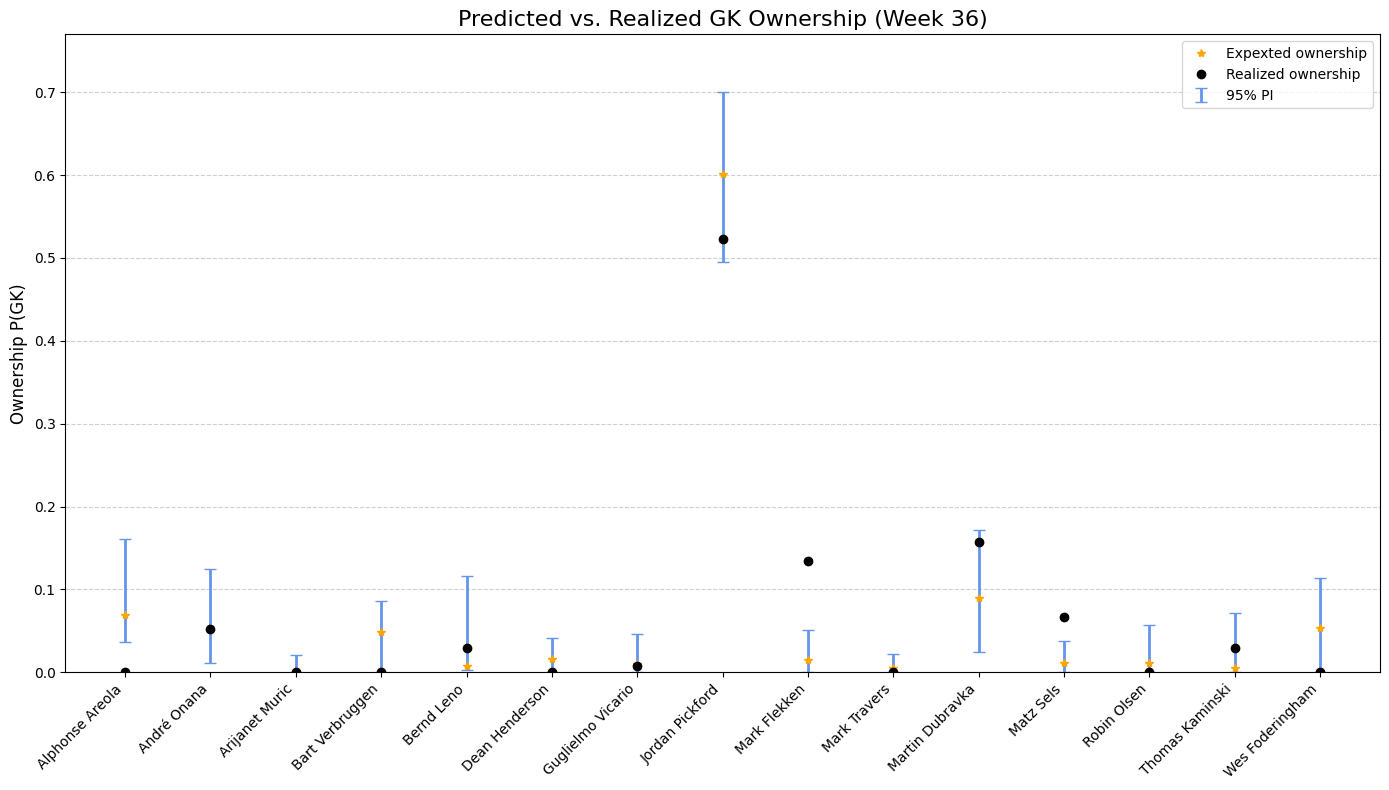

In [276]:
# Get all posterior samples for the 'betas' variable from the trace
num_samples = beta_gk.shape[0]
print(f"Extracted {num_samples} posterior samples for beta.")


# --- 3. Generate a Prediction for Each Sample ---
# For each of the 2000 beta samples, we generate one possible ownership vector
all_predictions = []


for i in range(num_samples):
    beta_sample = beta_gk[i]

    # Calculate alpha = exp(X * beta)
    alpha_sample = np.exp(np.dot(X_pca[0], beta_gk))
    # Sample a prediction from the Dirichlet distribution
    prediction = np.random.dirichlet(alpha_sample)
    all_predictions.append(prediction)

# Convert list of predictions into a numpy array (samples x num_players)
predictions_array = np.array(all_predictions)


# --- 4. Calculate the 95% Prediction Intervals ---
# For each player, find the 2.5th and 97.5th percentile of their predicted ownerships
lower_bounds = np.percentile(predictions_array, 2.5, axis=0)
upper_bounds = np.percentile(predictions_array, 97.5, axis=0)
mean_preds = np.mean(predictions_array, axis=0) # We need a y-value for the error bar center


# --- 5. Plot the Results ---
plt.figure(figsize=(14, 8))
y_err = [mean_preds - lower_bounds, upper_bounds - mean_preds]
# y_err = [exp_probs - hdi_lower, exp_probs - hdi_upper]
# y_err = np.vstack([
#     np.maximum(exp_probs - hdi_lower, 0),
#     np.maximum(hdi_upper - exp_probs, 0)
# ])

# Plot the 95% Prediction Intervals as blue error bars
plt.errorbar(
    x=gk_names,
    y=mean_preds,
    yerr=y_err,
    fmt='none',
    ecolor='cornflowerblue',
    elinewidth=2,
    capsize=4,
    label='95% PI' # PI = Prediction Interval
)

# Plot the realized ownership as black dots on top
plt.plot(
    gk_names,
    gk_probs_est,
    '*',
    color='orange',
    markersize=6,
    label='Expexted ownership'
)

# Plot the realized ownership as black dots on top
plt.plot(
    gk_names,
    gk_probs_obs,
    'o',
    color='black',
    markersize=6,
    label='Realized ownership'
)

# --- 6. Formatting the Plot ---
plt.title('Predicted vs. Realized GK Ownership (Week 36)', fontsize=16)
plt.ylabel('Ownership P(GK)', fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.legend()
plt.ylim(0, max(np.max(upper_bounds), np.max(gk_probs_obs)) * 1.1) # Set y-axis limit
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

Extracted 43 posterior samples for beta.


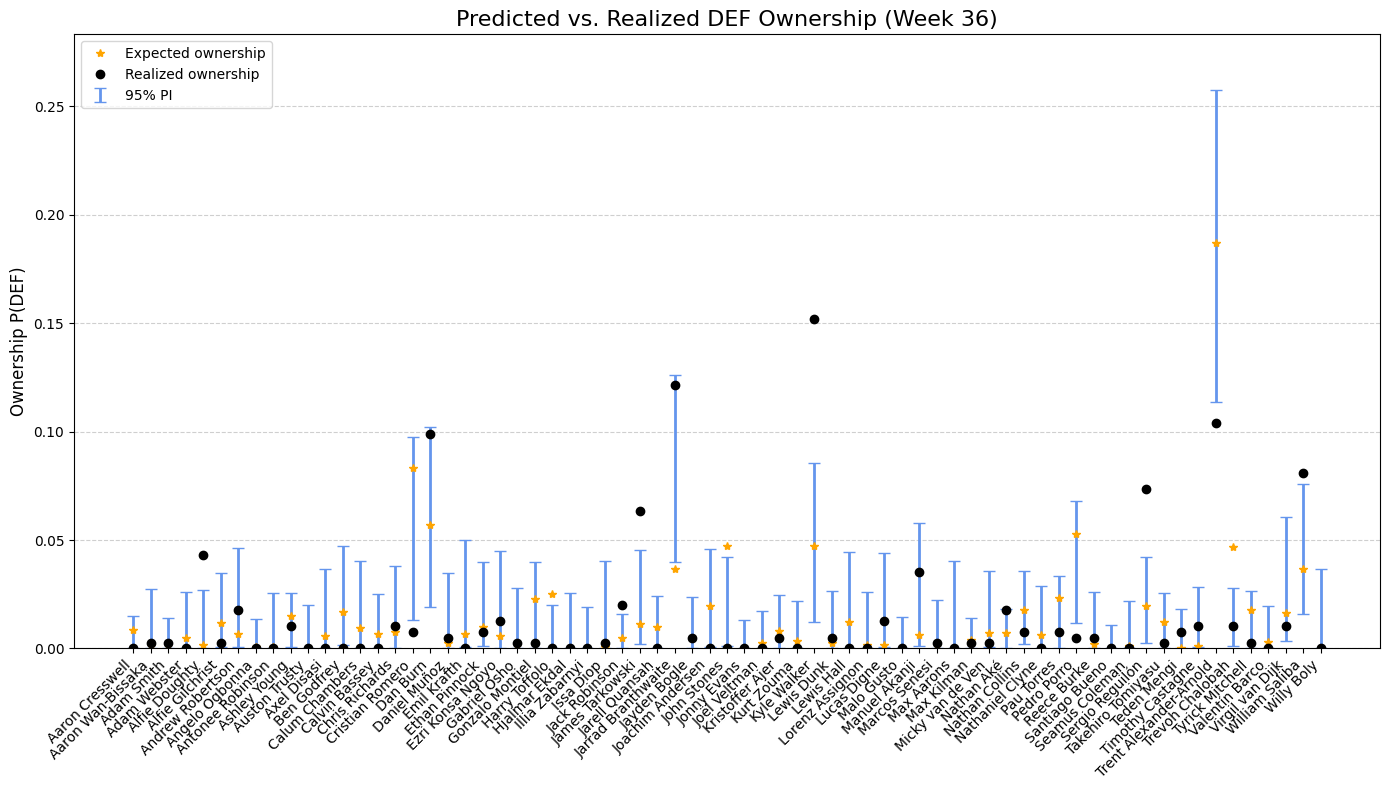

In [277]:
# Get all posterior samples for the 'betas' variable from the trace
num_samples = beta_def.shape[0]
print(f"Extracted {num_samples} posterior samples for beta.")

# --- 3. Generate a Prediction for Each Sample ---
# For each of the 2000 beta samples, we generate one possible ownership vector
all_predictions = []
for i in range(num_samples):
    beta_sample = beta_def[i]
    # Calculate alpha = exp(X * beta)
    alpha_sample = np.exp(np.dot(X_pca[1], beta_def))
    # Sample a prediction from the Dirichlet distribution
    prediction = np.random.dirichlet(alpha_sample)
    all_predictions.append(prediction)

# Convert list of predictions into a numpy array (samples x num_players)
predictions_array = np.array(all_predictions)


# --- 4. Calculate the 95% Prediction Intervals ---
# For each player, find the 2.5th and 97.5th percentile of their predicted ownerships
lower_bounds = np.percentile(predictions_array, 2.5, axis=0)
upper_bounds = np.percentile(predictions_array, 97.5, axis=0)
mean_preds = np.mean(predictions_array, axis=0) # We need a y-value for the error bar center

# --- 5. Plot the Results ---
plt.figure(figsize=(14, 8))

y_err = [
    mean_preds - lower_bounds,
    upper_bounds - mean_preds
    ]

# Plot the 95% Prediction Intervals as blue error bars
plt.errorbar(
    x=def_names,
    y=mean_preds,
    yerr=y_err,
    fmt='none',
    ecolor='cornflowerblue',
    elinewidth=2,
    capsize=4,
    label='95% PI' # PI = Prediction Interval
)

# Plot the expected ownership as black dots on top
plt.plot(
    def_names,
    def_probs_est,
    '*',
    color='orange',
    markersize=6,
    label='Expected ownership'
)


# Plot the realized ownership as black dots on top
plt.plot(
    def_names,
    def_probs_obs,
    'o',
    color='black',
    markersize=6,
    label='Realized ownership'
)

# --- 6. Formatting the Plot ---
plt.title('Predicted vs. Realized DEF Ownership (Week 36)', fontsize=16)
plt.ylabel('Ownership P(DEF)', fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.legend()
plt.ylim(0, max(np.max(upper_bounds), np.max(def_probs_obs)) * 1.1) # Set y-axis limit
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

Extracted 41 posterior samples for beta.
(41, 108)
(108,) (108,)


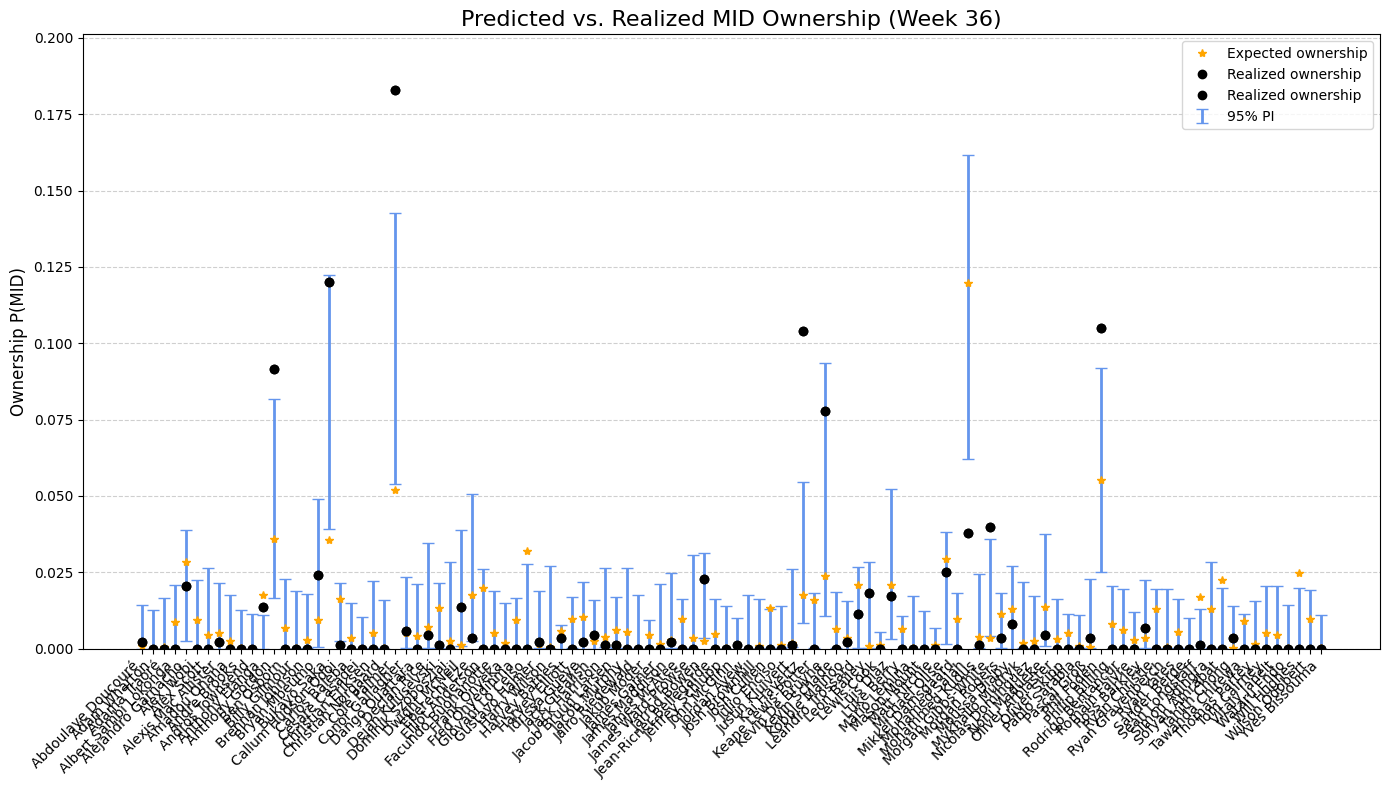

In [278]:
# Get all posterior samples for the 'betas' variable from the trace
num_samples = beta_mid.shape[0]
print(f"Extracted {num_samples} posterior samples for beta.")

# --- 3. Generate a Prediction for Each Sample ---
# For each of the 2000 beta samples, we generate one possible ownership vector
all_predictions = []
for i in range(num_samples):
    beta_sample = beta_mid[i]
    # Calculate alpha = exp(X * beta)
    alpha_sample = np.exp(np.dot(X_pca[2], beta_mid))
    # Sample a prediction from the Dirichlet distribution
    prediction = np.random.dirichlet(alpha_sample)
    all_predictions.append(prediction)

# Convert list of predictions into a numpy array (samples x num_players)
predictions_array = np.array(all_predictions)
print(predictions_array.shape)

# --- 4. Calculate the 95% Prediction Intervals ---
# For each player, find the 2.5th and 97.5th percentile of their predicted ownerships
lower_bounds = np.percentile(predictions_array, 2.5, axis=0)
upper_bounds = np.percentile(predictions_array, 97.5, axis=0)
mean_preds = np.mean(predictions_array, axis=0) # We need a y-value for the error bar center


# --- 5. Plot the Results ---
plt.figure(figsize=(14, 8))
y_err = [mean_preds - lower_bounds, upper_bounds - mean_preds]

# Plot the 95% Prediction Intervals as blue error bars
print(mid_names.shape, mean_preds.shape)
plt.errorbar(
    x=mid_names,
    y=mean_preds,
    yerr=y_err,
    fmt='none',
    ecolor='cornflowerblue',
    elinewidth=2,
    capsize=4,
    label='95% PI' # PI = Prediction Interval
)
# Plot the expected ownership as black dots on top
plt.plot(
    mid_names,
    mid_probs_est,
    '*',
    color='orange',
    markersize=6,
    label='Expected ownership'
)

# Plot the realized ownership as black dots on top
plt.plot(
    mid_names,
    mid_probs_obs,
    'o',
    color='black',
    markersize=6,
    label='Realized ownership'
)

# --- 6. Formatting the Plot ---
plt.title('Predicted vs. Realized MID Ownership (Week 36)', fontsize=16)
plt.ylabel('Ownership P(MID)', fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.legend()
plt.ylim(0, max(np.max(upper_bounds), np.max(mid_probs_obs)) * 1.1) # Set y-axis limit
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

Extracted 40 posterior samples for beta.


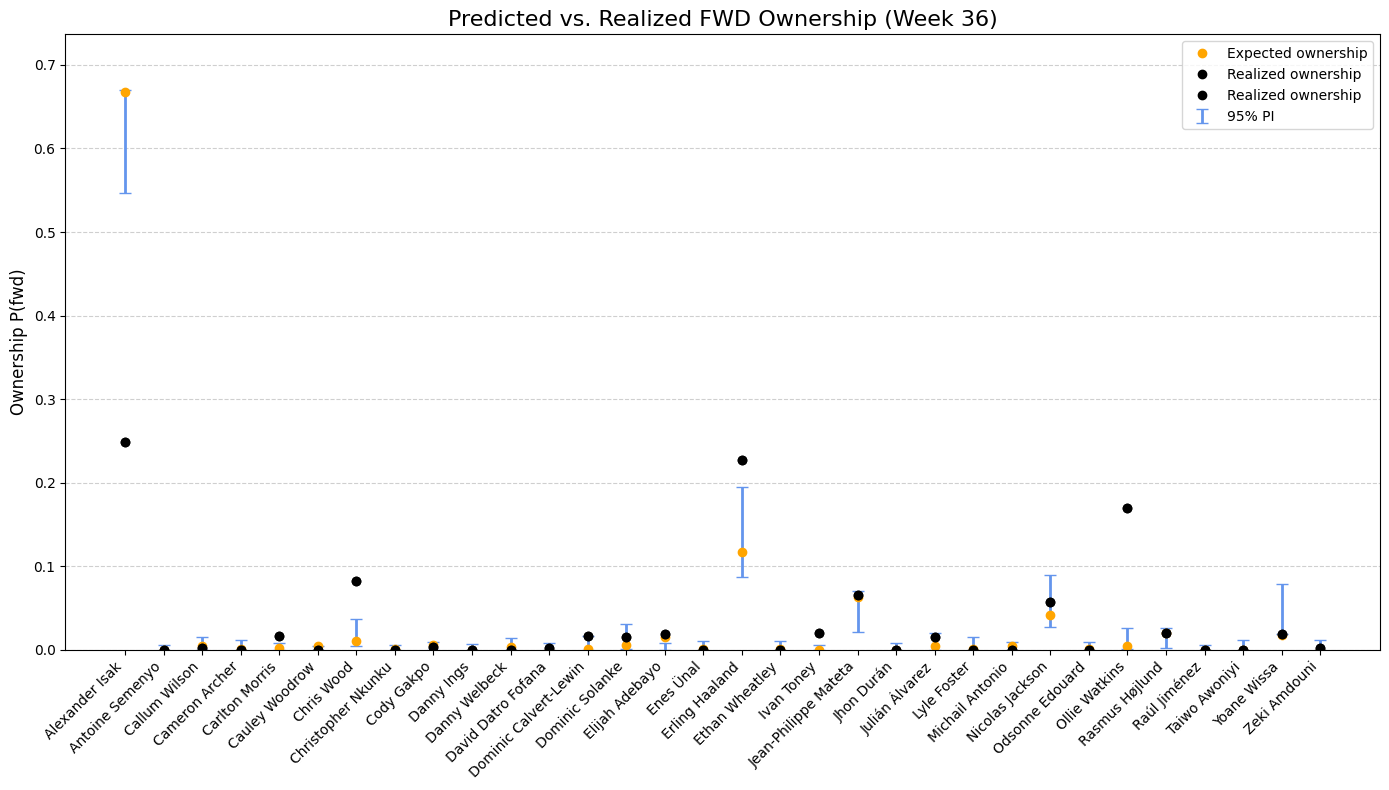

In [279]:
# Get all posterior samples for the 'betas' variable from the trace
num_samples = beta_fwd.shape[0]
print(f"Extracted {num_samples} posterior samples for beta.")

# --- 3. Generate a Prediction for Each Sample ---
# For each of the 2000 beta samples, we generate one possible ownership vector
all_predictions = []
for i in range(num_samples):
    beta_sample = beta_fwd[i]
    # Calculate alpha = exp(X * beta)
    alpha_sample = np.exp(np.dot(X_pca[3], beta_fwd))
    # Sample a prediction from the Dirichlet distribution
    prediction = np.random.dirichlet(alpha_sample)
    all_predictions.append(prediction)

# Convert list of predictions into a numpy array (samples x num_players)
predictions_array = np.array(all_predictions)

# --- 4. Calculate the 95% Prediction Intervals ---
# For each player, find the 2.5th and 97.5th percentile of their predicted ownerships
lower_bounds = np.percentile(predictions_array, 2.5, axis=0)
upper_bounds = np.percentile(predictions_array, 97.5, axis=0)
mean_preds = np.mean(predictions_array, axis=0) # We need a y-value for the error bar center


# --- 5. Plot the Results ---
plt.figure(figsize=(14, 8))
y_err = [mean_preds - lower_bounds, upper_bounds - mean_preds]

# Plot the 95% Prediction Intervals as blue error bars
plt.errorbar(
    x=fwd_names,
    y=mean_preds,
    yerr=y_err,
    fmt='none',
    ecolor='cornflowerblue',
    elinewidth=2,
    capsize=4,
    label='95% PI' # PI = Prediction Interval
)

# Plot the expected ownership as black dots on top
plt.plot(
    fwd_names,
    fwd_probs_est,
    'o',
    color='orange',
    markersize=6,
    label='Expected ownership'
)

# Plot the realized ownership as black dots on top
plt.plot(
    fwd_names,
    fwd_probs_obs,
    'o',
    color='black',
    markersize=6,
    label='Realized ownership'
)

# --- 6. Formatting the Plot ---
plt.title('Predicted vs. Realized FWD Ownership (Week 36)', fontsize=16)
plt.ylabel('Ownership P(fwd)', fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.legend()
plt.ylim(0, max(np.max(upper_bounds), np.max(fwd_probs_obs)) * 1.1) # Set y-axis limit
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

## Generate Portfolios


In [280]:

def is_feasible(portfolio, budget, budget_lower_bound, costs, stacker, teams):
    """
    Placeholder function to check if a portfolio is feasible.
    [span_6](start_span)[span_7](start_span)This checks the budget constraint and other linear constraints represented by W[span_6](end_span)[span_7](end_span).
    In a real scenario, this would include checks for positional limits (e.g., exactly 1 QB).
    """


    costs_ = []
    for sublist in costs:
        costs_.extend(sublist)

    costs = costs_

    total_cost = np.dot(portfolio, costs)
    # teams = pd.concat(teams).values
    # print(teams)
    if total_cost > budget or total_cost < budget_lower_bound:
        return False
    # Add other positional/diversity constraint checks here

    # # --- Positional checks ---
    # pos_counts = {
    #     "GK": np.sum(portfolio[positions == "GK"]),
    #     "DEF": np.sum(portfolio[positions == "DEF"]),
    #     "MID": np.sum(portfolio[positions == "MID"]),
    #     "FWD": np.sum(portfolio[positions == "FWD"]),
    # }

    # if not (pos_counts["GK"] == 1): return False
    # if not (3 <= pos_counts["DEF"] <= 5): return False
    # if not (2 <= pos_counts["MID"] <= 5): return False
    # if not (1 <= pos_counts["FWD"] <= 3): return False
    # if sum(pos_counts.values()) != 11: return False

    if stacker:
        pass
        # # Find which players are picked
        # chosen_indices = np.where(portfolio == 1)[0]
        # chosen_teams = [teams[i] for i in chosen_indices]

        # # Count team occurrences
        # team_counts = {}
        # for t in chosen_teams:
        #     team_counts[t] = team_counts.get(t, 0) + 1

        # # If no stack exists, force it by replacing one player
        # if max(team_counts.values()) < 2:
        #     # e.g. pick a random team among chosen ones and add another from it
        #     target_team = np.random.choice(chosen_teams)
        #     same_team_indices = [i for i, t in enumerate(teams) if t == target_team]

        #     # try adding one more player from that team (if not already chosen)
        #     for idx in same_team_indices:
        #         if portfolio[idx] == 0:
        #             portfolio[idx] = 1
        #             # then drop a random other player to keep total = 11
        #             other_idx = np.random.choice(chosen_indices)
        #             portfolio[other_idx] = 0
        #             break


    # --- Max 3 players per team ---
    team_counts = {}
    teams_ = []
    for sublist in teams:
        teams_.extend(sublist)

    teams = teams_

    team_idx = [idx for idx, _ in enumerate(portfolio) if portfolio[idx] == 1]
    selected_teams = [teams[i] for i in team_idx]

    if any(team >=3 for team in Counter(selected_teams).values()):
        return False
    print(total_cost)
    return True

def sample_opponent_portfolios(O, beta_estimates, feature_matrices, costs, budget,teams, q=0.35, Blb_ratio=0.90):
    """
    Args:
        O (int): Number of opponent portfolios to generate.
        beta_estimates (dict): A dictionary mapping position ('QB', 'RB', etc.) to its estimated beta coefficients.
        feature_matrices (dict): A dictionary mapping position to its feature matrix X.
        costs (np.ndarray): An array of costs for all players.
        budget (float): The total salary cap.
        [span_9](start_span)q (float): The probability of a "stacker" contestant[span_9](end_span).
        [span_10](start_span)Blb_ratio (float): The minimum budget usage ratio[span_10](end_span).

    Returns:
        list: A list of O feasible opponent portfolios (as numpy arrays).
    """

    # --- Step 1: Calculate alpha parameters ---
    # [span_11](start_span)alpha = exp(X * beta) for each position[span_11](end_span)

    alphas = {
        'GK': np.exp(np.dot(feature_matrices[0], beta_estimates['GK'])),
        'DEF': np.exp(np.dot(feature_matrices[1], beta_estimates['DEF'])),
        'MID': np.exp(np.dot(feature_matrices[2], beta_estimates['MID'])),
        'FWD': np.exp(np.dot(feature_matrices[3], beta_estimates['FWD']) )
    }
    # --- Step 2: Sample p vectors from Dirichlet distributions ---
    # [span_12](start_span)p ~ Dir(alpha) for each position[span_12](end_span)
    p_vectors = {pos: np.random.dirichlet(alpha) for pos, alpha in alphas.items()}

    opponent_portfolios = set()
    print(f"\nGenerating {O} opponent portfolios...")

    # --- Step 3-18: Main loop to generate O portfolios ---
    for o in range(O):
        reject = True
        # [span_13](start_span)
        while reject: # Accept-Reject loop[span_13](end_span)
            def get_random_fpl_formation():
                """
                Generates all valid 11-player FPL formations and returns one at random.
                """
                def_sizes = [3, 4, 5]
                mid_sizes = [2, 3, 4, 5]
                fwd_sizes = [1, 2, 3]

                valid_formations = []

                # Iterate through all combinations to find those that sum to 10 (plus 1 GK)
                for de in def_sizes:
                    for mid in mid_sizes:
                        for fwd in fwd_sizes:
                            if de + mid + fwd == 10:
                                valid_formations.append([de, mid, fwd])

                # Return a single random choice from the list
                return random.choice(valid_formations)

            # --- Get and print a random formation ---
            random_formation = get_random_fpl_formation()

            # Create an array of indices for each position
            gk_indices = np.arange(len(p_vectors['GK']))
            def_indices = np.arange(len(p_vectors['DEF']))
            mid_indices = np.arange(len(p_vectors['MID']))
            fwd_indices = np.arange(len(p_vectors['FWD']))

            # Sample player indices WITHOUT replacement
            selected_gk_indices = np.random.choice(gk_indices, size=1, replace=False, p=p_vectors['GK'])
            selected_def_indices = np.random.choice(def_indices, size=random_formation[0], replace=False, p=p_vectors['DEF'])
            selected_mid_indices = np.random.choice(mid_indices, size=random_formation[1], replace=False, p=p_vectors['MID'])
            selected_fwd_indices = np.random.choice(fwd_indices, size=random_formation[2], replace=False, p=p_vectors['FWD'])

            # --- Create the binary selection arrays ---
            # This creates the [0, 1, 0, 1, ...] format your code expects

            selected_g = np.zeros(len(p_vectors['GK']), dtype=int)
            selected_g[selected_gk_indices] = 1

            selected_d = np.zeros(len(p_vectors['DEF']), dtype=int)
            selected_d[selected_def_indices] = 1

            selected_m = np.zeros(len(p_vectors['MID']), dtype=int)
            selected_m[selected_mid_indices] = 1

            selected_f = np.zeros(len(p_vectors['FWD']), dtype=int)
            selected_f[selected_fwd_indices] = 1

            selections = {
                'GK': selected_g,
                'DEF': selected_d,
                'MID': selected_m,
                'FWD': selected_f,
            }

            # --- Step 9-11: Implement stacking logic ---
            # --- Step 4: Determine if the opponent is a "stacker" ---
            is_stacker = np.random.binomial(1, q) == 1

            if is_stacker:
                # This is a simplified version of stacking. A real implementation
                # would need a mapping of which WR is the "main" WR for each QB.
                # Here, we just ensure a WR from the same team is chosen.
                # [span_15](start_span)"Replace k_WR(1) with main WR from team of k_QB"[span_15](end_span)
                # team_counts = {}
                # for idx, picked in enumerate(portfolio):
                #     if picked == 1:
                #         team = teams[idx]
                #         team_counts[team] = team_counts.get(team, 0) + 1
                # # require at least 2 from same team
                # if max(team_counts.values()) < 2:
                #     continue
                pass # Placeholder for your specific stacking logic

            # --- Step 12: Form the candidate portfolio w_o ---
            # This requires combining the positional selection arrays into one large portfolio vector
            candidate_portfolio = np.concatenate(list(selections.values())) # Example, needs proper indexing

            # --- Step 13-16: Feasibility Check ---
            budget_lower_bound = budget * Blb_ratio

            # print( candidate_portfolio)
            if is_feasible(candidate_portfolio, budget, budget_lower_bound, costs, is_stacker, teams):
                reject = False

                ids_ = []
                for sublist in ids:
                    ids_.extend(sublist)

                squad_ids = [cid for cid, count in zip(ids_, candidate_portfolio) if count > 0]

                squad_frozenset = frozenset(squad_ids)

                if squad_frozenset not in opponent_portfolios:
                    opponent_portfolios.add(squad_frozenset) # Accept Wo
                print('--------------------------->>>>>>>>', len(opponent_portfolios))

    print(f"✅ Successfully generated {len(opponent_portfolios)} portfolios.")
    return opponent_portfolios

# --- Step 19: Return W_op ---
# Generate O opponent portfolios[span_17](end_span)
generated_portfolios = sample_opponent_portfolios(
    O=200,
    beta_estimates=all_beta_estimates,
    feature_matrices=X_pca,
    costs=prices,
    budget=100,
    teams = teams
)

# prices[3].shape


Generating 200 opponent portfolios...
90.2
--------------------------->>>>>>>> 1
91.4
--------------------------->>>>>>>> 2
90.5
--------------------------->>>>>>>> 3
91.1
--------------------------->>>>>>>> 4
90.1
--------------------------->>>>>>>> 5
90.7
--------------------------->>>>>>>> 6
90.39999999999999
--------------------------->>>>>>>> 7
90.30000000000001
--------------------------->>>>>>>> 8
91.0
--------------------------->>>>>>>> 9
90.1
--------------------------->>>>>>>> 10
90.0
--------------------------->>>>>>>> 11
90.30000000000001
--------------------------->>>>>>>> 12
91.0
--------------------------->>>>>>>> 13
92.7
--------------------------->>>>>>>> 14
90.4
--------------------------->>>>>>>> 15
92.1
--------------------------->>>>>>>> 16
91.9
--------------------------->>>>>>>> 17
91.0
--------------------------->>>>>>>> 18
90.2
--------------------------->>>>>>>> 19
90.8
--------------------------->>>>>>>> 20
90.0
--------------------------->>>>>>>> 21
91.3000

In [281]:
Wo_ = []
for i in generated_portfolios:
    # Create a tuple of 0s and 1s for each player
    squad = tuple([1 if id_ in i else 0 for id_ in valid_player_ids])
    Wo_.append(squad)

Output()

Finished [100%]: Average Loss = 19,488
arviz - WARNING - Shape validation failed: input_shape: (1, 1000), minimum_shape: (chains=2, draws=4)


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
delta[0],4.416,0.022,4.376,4.457,0.001,0.000,893.0,972.0,NaN
delta[1],0.592,0.018,0.557,0.624,0.001,0.000,970.0,875.0,NaN
delta[2],5.551,0.023,5.505,5.590,0.001,0.001,924.0,1023.0,NaN
delta[3],4.714,0.020,4.673,4.746,0.001,0.000,1044.0,887.0,NaN
delta[4],0.455,0.016,0.424,0.484,0.001,0.000,1037.0,1021.0,NaN
...,...,...,...,...,...,...,...,...,...
G_r[195],33.453,0.067,33.336,33.580,0.002,0.001,1104.0,988.0,NaN
G_r[196],29.997,0.067,29.858,30.114,0.002,0.001,1016.0,994.0,NaN
G_r[197],33.534,0.068,33.411,33.661,0.002,0.002,931.0,1022.0,NaN
G_r[198],33.591,0.069,33.443,33.704,0.002,0.002,1055.0,923.0,NaN


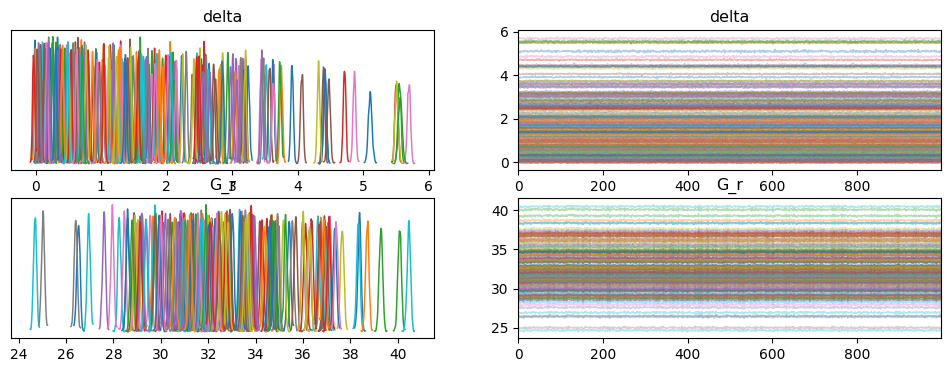

In [282]:
def make_positive_definite(cov_mat, epsilon=1e-6):
    # Ensure symmetry
    cov_mat = (cov_mat + cov_mat.T) / 2

    # Add jitter to diagonal
    jitter = epsilon * np.eye(cov_mat.shape[0])
    return cov_mat + jitter


def monte_carlo_simulation(Wo_, mu_delta, cov_mat, sigma_delta):
    num_player = len(Wo_[0])

    cov_mat = make_positive_definite(cov_mat)

    with pm.Model() as model:
        L = np.linalg.cholesky(make_positive_definite(cov_mat))
        delta = pm.MvNormal("delta", mu=mu_delta, chol=L, shape=num_player)
        # delta = pm.MvNormal("delta", mu=mu_delta, cov=cov_mat, shape=num_player)

        # Compute 90th percentile of performance
        dot_product = pt.dot(Wo_, delta)
        G_r = pm.Deterministic("G_r",  np.percentile(dot_product, 90)) # pt.sort(dot_product)[-int(len(Wo_) * 0.9)])

        approx = pm.fit(method='advi', n=20000)

        trace = approx.sample(1000)
        # trace = pm.sample(
        #     3000,
        #     return_inferencedata=True,
        #     cores=2,
        #     chains=10,
        #     progressbar=True,
        #     target_accept=0.95
        # )

        # G_r_90 = np.percentile(pt.dot(trace.posterior['delta'].values, Wo_), 90)

    return trace
MC_sim_trace = monte_carlo_simulation(Wo_, mu_delta, cov_mat, sigma_delta)

az.plot_trace(MC_sim_trace, var_names=["delta", "G_r"])
az.summary(MC_sim_trace, var_names=["delta", "G_r"])

In [283]:
delta_samples = MC_sim_trace.posterior['delta'].stack(sample=("chain", "draw")).values.T  # shape (N_samples, 226)
G_r_samples   = MC_sim_trace.posterior['G_r'].stack(sample=("chain", "draw")).values.T    # shape (N_samples, 200)

G_r_scalar = np.percentile(G_r_samples, 90, axis=1)  # shape (N_samples,)
print(G_r_scalar.shape, delta_samples.shape)

mu_delta, cov_delta, mu_G, var_G, cov_delta_G, sigma_G = generate_cov_delta(delta_samples, G_r_scalar)


(1000,) (1000, 226)
(1000, 226) (1000,)


In [284]:
lambdas = np.linspace(0.0, 0.5, 6)
best_lambda, best_w, best_prob = optimize_portfolio(W_constraints, mu_delta, cov_delta, mu_G, var_G, cov_delta_G, lambdas, delta_samples, G_r_scalar)
print(f"Best λ: {best_lambda}, Best Probability of Outperforming: {best_prob}")
selected, player_names, total_points = selected_info(best_w, fpl_teams_ids, players_preds, ids)
selected, player_names, total_points

Gurobi Optimizer version 12.0.1 build v12.0.1rc0 (win64 - Windows 11.0 (22631.2))

CPU model: Intel(R) Core(TM) i5-7200U CPU @ 2.50GHz, instruction set [SSE2|AVX|AVX2]
Thread count: 2 physical cores, 4 logical processors, using up to 4 threads

Optimize a model with 29 rows, 226 columns and 889 nonzeros
Model fingerprint: 0x9d320d23
Variable types: 0 continuous, 226 integer (226 binary)
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  Objective range  [3e-04, 6e+00]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+00, 1e+01]
Found heuristic solution: objective -11.0007012
Presolve added 10 rows and 0 columns
Presolve removed 0 rows and 37 columns
Presolve time: 0.00s
Presolved: 39 rows, 189 columns, 645 nonzeros
Found heuristic solution: objective 11.0445943
Variable types: 0 continuous, 189 integer (178 binary)

Root relaxation: objective 1.639107e+01, 16 iterations, 0.00 seconds (0.00 work units)

    Nodes    |    Current Node    |     Objective Bounds      |     

([19, 20, 60, 308, 313, 343, 353, 355, 362, 506, 597],
 ['Bukayo Saka',
  'William Saliba',
  'Ollie Watkins',
  'Mohamed Salah',
  'Virgil van Dijk',
  'Julián Álvarez',
  'Phil Foden',
  'Erling Haaland',
  'Cole Palmer',
  'Pedro Porro',
  'André Onana'],
 73)

# GW 37


In [314]:
players_preds = pd.read_csv(f'../FPL predictors/Fantasy Go/fantasyGo_preds_37.csv', index_col=0)
players_preds['xP_cost'] = round(players_preds['xP']/players_preds['value'], 2)

data_23_24['xP_cost'] = round(data_23_24['xP']/data_23_24['value'], 2)
data_23_24_37 = data_23_24[data_23_24['event'] < 37]

# # Add fpl_id to player_preds
players_preds = players_preds.merge(fpl_teams_ids, left_on='fpl_name', right_on='FPL_Name', how='left')

## Generate Cov_Mat


In [286]:
mu_delta, sigma_delta, cov_mat, valid_player_ids = generate_cov_mat(players_preds, data_23_24_37)
# cov_mat

Starting to optimize team selection...


## Data Preparations


In [287]:
data_cols.append('fpl_id')
data_cols_gk.append('fpl_id')

gk_data = players_preds[players_preds['position'] == 'GK'][data_cols_gk].dropna()
def_data = players_preds[players_preds['position'] == 'DEF'][data_cols].dropna()
mid_data = players_preds[players_preds['position'] == 'MID'][data_cols].dropna()
fwd_data = players_preds[players_preds['position'] == 'FWD'][data_cols].dropna()
data = [gk_data, def_data, mid_data, fwd_data]

player_ids = np.concatenate([gk_data['fpl_id'].to_list(), def_data['fpl_id'].to_list(), mid_data['fpl_id'].to_list(),  fwd_data['fpl_id'].to_list()])

gk_data.drop(columns='fpl_id', inplace=True)
def_data.drop(columns='fpl_id', inplace=True)
mid_data.drop(columns='fpl_id', inplace=True)
fwd_data.drop(columns='fpl_id', inplace=True)

data_cols.remove('fpl_id')
data_cols_gk.remove('fpl_id')

data_23_24_36 = data_23_24_36[data_23_24_36['fpl_id'].isin(valid_player_ids)].reset_index(drop=True)
players_preds = players_preds[players_preds['fpl_id'].isin(valid_player_ids)].reset_index(drop=True)
data, prices, xPts, positions , teams, ids, X_pca = clean_data(players_preds, valid_player_ids)

starting to clean data...
data successfully cleaned...


In [288]:
ownership_gk = players_preds[players_preds['position'] == 'GK']['ownership_percent']
gk_names = players_preds[players_preds['position'] == 'GK']['FPL_Name']
gk_probs_obs = ownership_gk / ownership_gk.sum()

ownership_def = players_preds[players_preds['position'] == 'DEF']['ownership_percent']
def_names = players_preds[players_preds['position'] == 'DEF']['FPL_Name']
def_probs_obs = ownership_def / ownership_def.sum()

cols = data_cols.copy()
cols.append('ownership_percent')
cols.append('FPL_Name')

mids = players_preds[players_preds['position'] == 'MID'][cols].dropna()
ownership_mid = mids['ownership_percent']
mid_names = mids['FPL_Name']
mid_probs_obs = ownership_mid / ownership_mid.sum()

fwds = players_preds[players_preds['position'] == 'FWD'][cols].dropna()
ownership_fwds = fwds['ownership_percent']
fwd_names = fwds['FPL_Name']
fwd_probs_obs = ownership_fwds / ownership_fwds.sum()

In [289]:
alphas = {
        'GK': np.exp(np.dot(X_pca[0], beta_gk)),
        'DEF': np.exp(np.dot(X_pca[1], beta_def)),
        'MID': np.exp(np.dot(X_pca[2], beta_mid)),
        'FWD': np.exp(np.dot(X_pca[3], beta_fwd))
    }


p_vectors = {pos: np.random.dirichlet(alpha) for pos, alpha in alphas.items()}

gk_probs_est = p_vectors['GK'].tolist()
def_probs_est = p_vectors['DEF'].tolist()
mid_probs_est = p_vectors['MID'].tolist()
fwd_probs_est = p_vectors['FWD'].tolist()


## Plots


Extracted 38 posterior samples for beta.


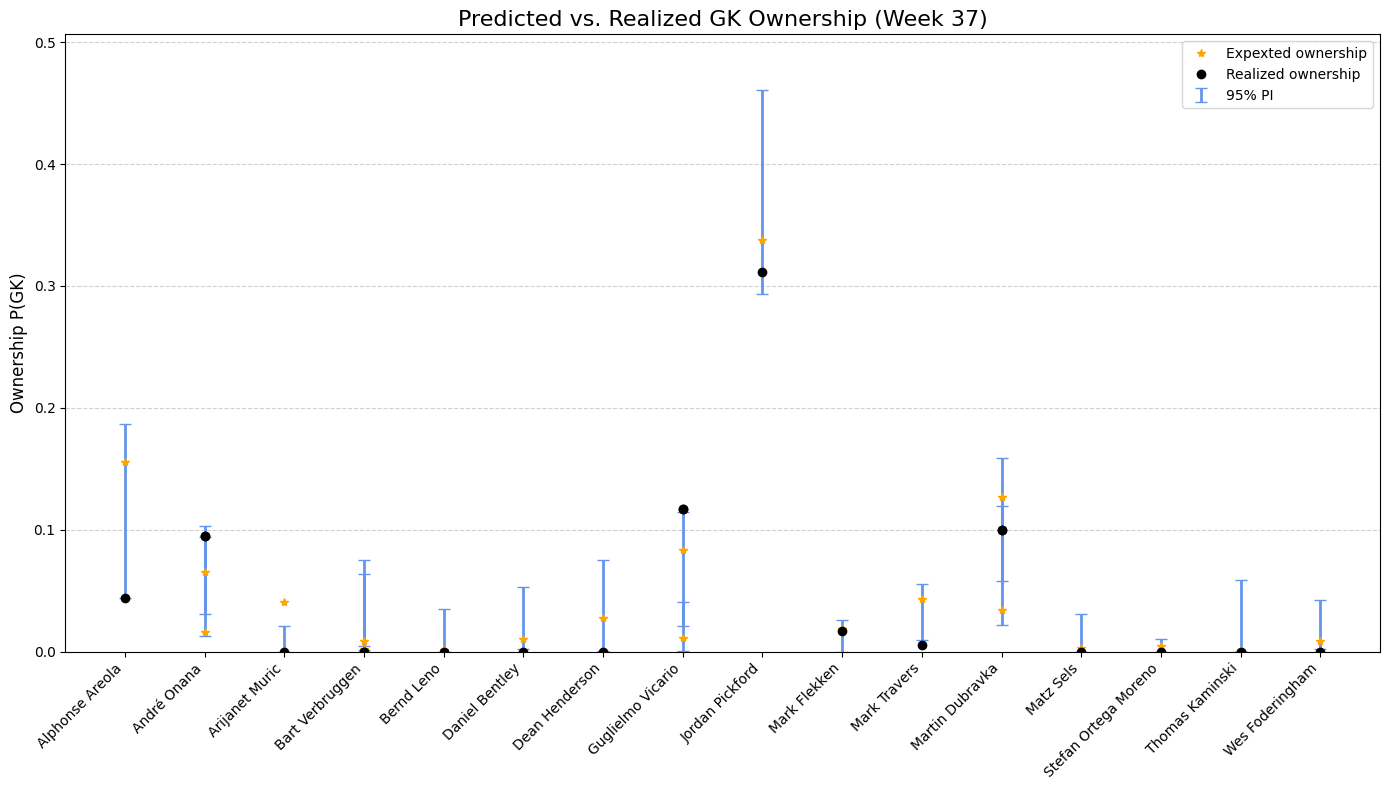

In [290]:
# Get all posterior samples for the 'betas' variable from the trace
num_samples = beta_gk.shape[0]
print(f"Extracted {num_samples} posterior samples for beta.")


# --- 3. Generate a Prediction for Each Sample ---
# For each of the 2000 beta samples, we generate one possible ownership vector
all_predictions = []


for i in range(num_samples):
    beta_sample = beta_gk[i]

    # Calculate alpha = exp(X * beta)
    alpha_sample = np.exp(np.dot(X_pca[0], beta_gk))
    # Sample a prediction from the Dirichlet distribution
    prediction = np.random.dirichlet(alpha_sample)
    all_predictions.append(prediction)

# Convert list of predictions into a numpy array (samples x num_players)
predictions_array = np.array(all_predictions)

# --- 4. Calculate the 95% Prediction Intervals ---
# For each player, find the 2.5th and 97.5th percentile of their predicted ownerships
lower_bounds = np.percentile(predictions_array, 2.5, axis=0)
upper_bounds = np.percentile(predictions_array, 97.5, axis=0)
mean_preds = np.mean(predictions_array, axis=0) # We need a y-value for the error bar center


# --- 5. Plot the Results ---
plt.figure(figsize=(14, 8))
y_err = [mean_preds - lower_bounds, upper_bounds - mean_preds]


# Plot the 95% Prediction Intervals as blue error bars
plt.errorbar(
    x=gk_names,
    y=mean_preds,
    yerr=y_err,
    fmt='none',
    ecolor='cornflowerblue',
    elinewidth=2,
    capsize=4,
    label='95% PI' # PI = Prediction Interval
)

# Plot the realized ownership as black dots on top
plt.plot(
    gk_names,
    gk_probs_est,
    '*',
    color='orange',
    markersize=6,
    label='Expexted ownership'
)

# Plot the realized ownership as black dots on top
plt.plot(
    gk_names,
    gk_probs_obs,
    'o',
    color='black',
    markersize=6,
    label='Realized ownership'
)

# --- 6. Formatting the Plot ---
plt.title('Predicted vs. Realized GK Ownership (Week 37)', fontsize=16)
plt.ylabel('Ownership P(GK)', fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.legend()
plt.ylim(0, max(np.max(upper_bounds), np.max(gk_probs_obs)) * 1.1) # Set y-axis limit
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

Extracted 43 posterior samples for beta.


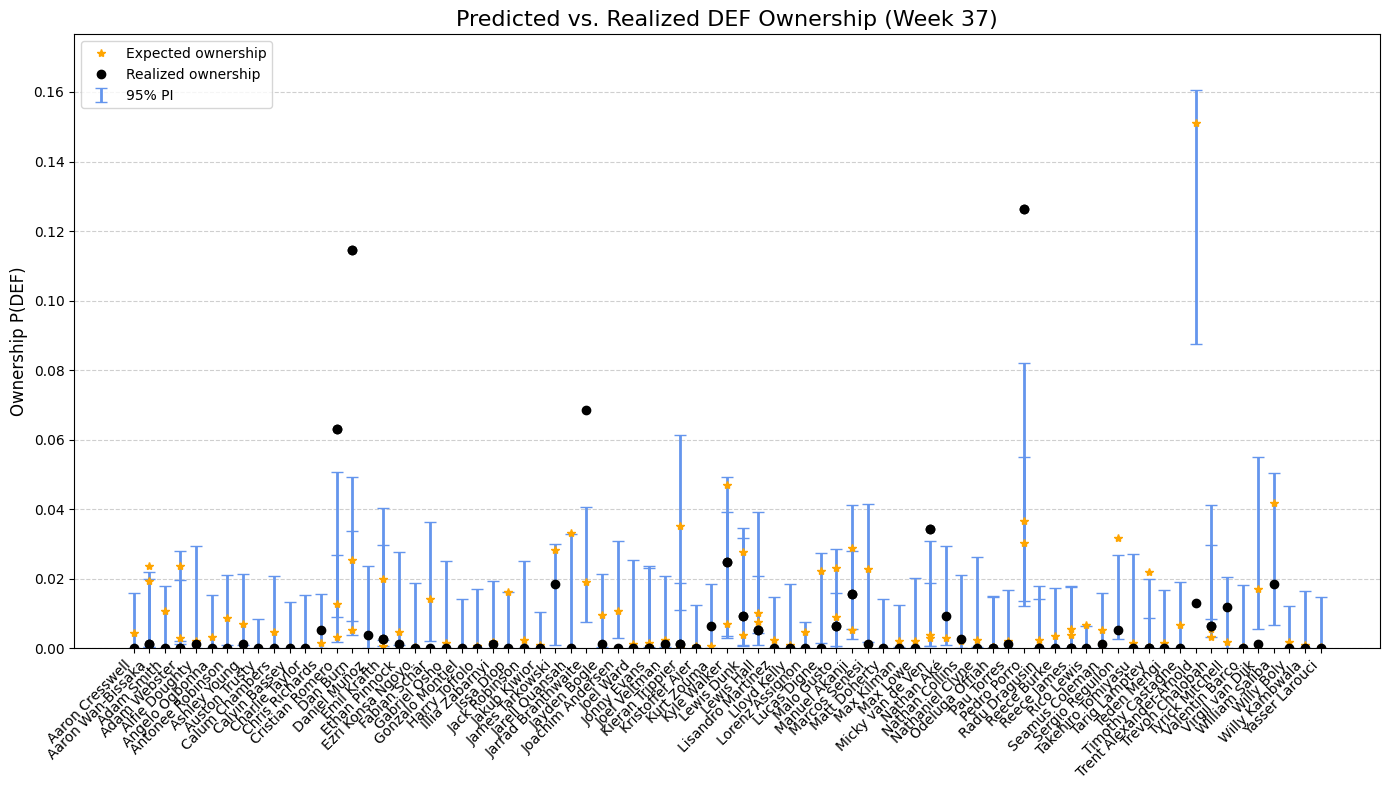

In [291]:
# Get all posterior samples for the 'betas' variable from the trace
num_samples = beta_def.shape[0]
print(f"Extracted {num_samples} posterior samples for beta.")

# --- 3. Generate a Prediction for Each Sample ---
# For each of the 2000 beta samples, we generate one possible ownership vector
all_predictions = []
for i in range(num_samples):
    beta_sample = beta_def[i]
    # Calculate alpha = exp(X * beta)
    alpha_sample = np.exp(np.dot(X_pca[1], beta_def))
    # Sample a prediction from the Dirichlet distribution
    prediction = np.random.dirichlet(alpha_sample)
    all_predictions.append(prediction)

# Convert list of predictions into a numpy array (samples x num_players)
predictions_array = np.array(all_predictions)


# --- 4. Calculate the 95% Prediction Intervals ---
# For each player, find the 2.5th and 97.5th percentile of their predicted ownerships
lower_bounds = np.percentile(predictions_array, 2.5, axis=0)
upper_bounds = np.percentile(predictions_array, 97.5, axis=0)
mean_preds = np.mean(predictions_array, axis=0) # We need a y-value for the error bar center

# --- 5. Plot the Results ---
plt.figure(figsize=(14, 8))

y_err = [
    mean_preds - lower_bounds,
    upper_bounds - mean_preds
    ]

# Plot the 95% Prediction Intervals as blue error bars
plt.errorbar(
    x=def_names,
    y=mean_preds,
    yerr=y_err,
    fmt='none',
    ecolor='cornflowerblue',
    elinewidth=2,
    capsize=4,
    label='95% PI' # PI = Prediction Interval
)

# Plot the expected ownership as black dots on top
plt.plot(
    def_names,
    def_probs_est,
    '*',
    color='orange',
    markersize=6,
    label='Expected ownership'
)


# Plot the realized ownership as black dots on top
plt.plot(
    def_names,
    def_probs_obs,
    'o',
    color='black',
    markersize=6,
    label='Realized ownership'
)

# --- 6. Formatting the Plot ---
plt.title('Predicted vs. Realized DEF Ownership (Week 37)', fontsize=16)
plt.ylabel('Ownership P(DEF)', fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.legend()
plt.ylim(0, max(np.max(upper_bounds), np.max(def_probs_obs)) * 1.1) # Set y-axis limit
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

Extracted 41 posterior samples for beta.
(41, 141)
(141,) (141,)


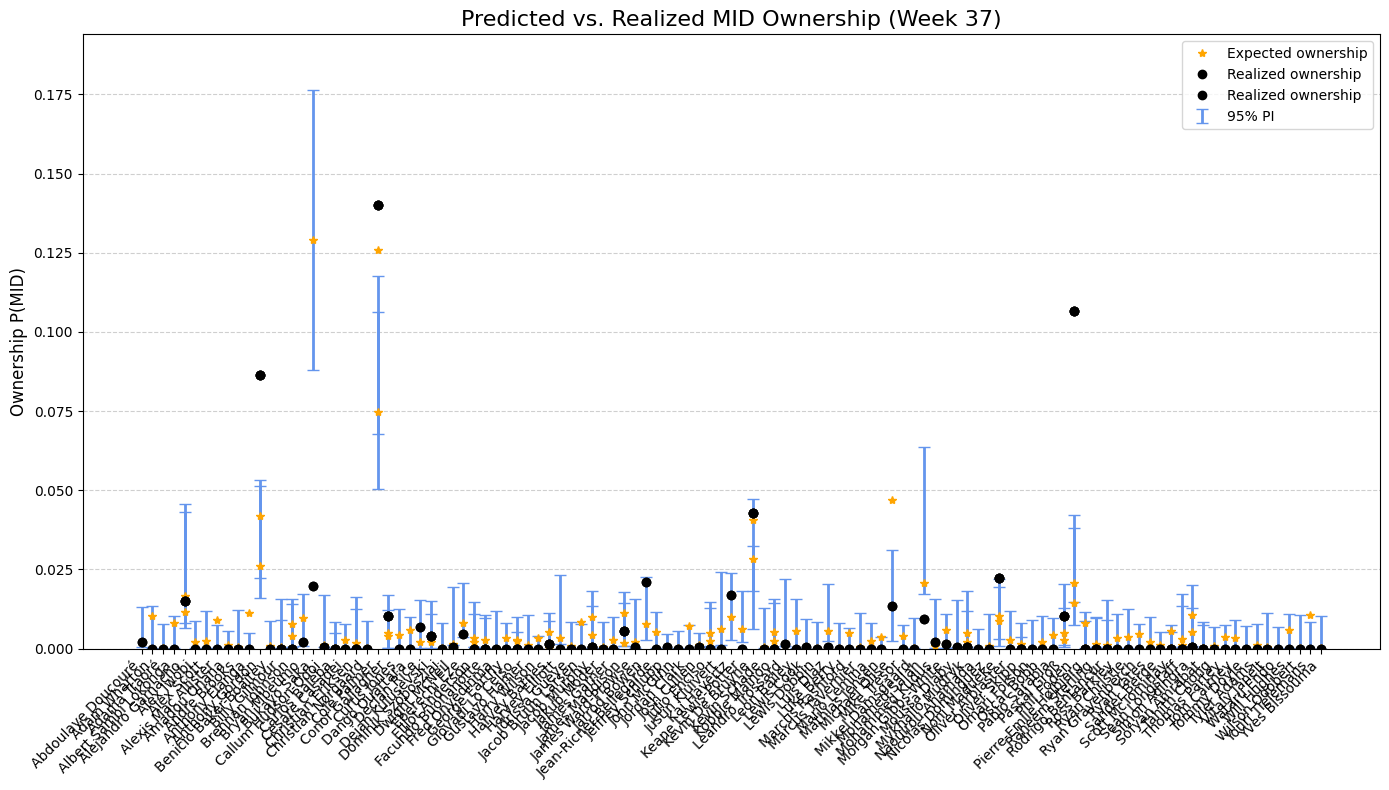

In [292]:
# Get all posterior samples for the 'betas' variable from the trace
num_samples = beta_mid.shape[0]
print(f"Extracted {num_samples} posterior samples for beta.")

# --- 3. Generate a Prediction for Each Sample ---
# For each of the 2000 beta samples, we generate one possible ownership vector
all_predictions = []
for i in range(num_samples):
    beta_sample = beta_mid[i]
    # Calculate alpha = exp(X * beta)
    alpha_sample = np.exp(np.dot(X_pca[2], beta_mid))
    # Sample a prediction from the Dirichlet distribution
    prediction = np.random.dirichlet(alpha_sample)
    all_predictions.append(prediction)

# Convert list of predictions into a numpy array (samples x num_players)
predictions_array = np.array(all_predictions)
print(predictions_array.shape)

# --- 4. Calculate the 95% Prediction Intervals ---
# For each player, find the 2.5th and 97.5th percentile of their predicted ownerships
lower_bounds = np.percentile(predictions_array, 2.5, axis=0)
upper_bounds = np.percentile(predictions_array, 97.5, axis=0)
mean_preds = np.mean(predictions_array, axis=0) # We need a y-value for the error bar center


# --- 5. Plot the Results ---
plt.figure(figsize=(14, 8))
y_err = [mean_preds - lower_bounds, upper_bounds - mean_preds]

# Plot the 95% Prediction Intervals as blue error bars
print(mid_names.shape, mean_preds.shape)
plt.errorbar(
    x=mid_names,
    y=mean_preds,
    yerr=y_err,
    fmt='none',
    ecolor='cornflowerblue',
    elinewidth=2,
    capsize=4,
    label='95% PI' # PI = Prediction Interval
)
# Plot the expected ownership as black dots on top
plt.plot(
    mid_names,
    mid_probs_est,
    '*',
    color='orange',
    markersize=6,
    label='Expected ownership'
)

# Plot the realized ownership as black dots on top
plt.plot(
    mid_names,
    mid_probs_obs,
    'o',
    color='black',
    markersize=6,
    label='Realized ownership'
)

# --- 6. Formatting the Plot ---
plt.title('Predicted vs. Realized MID Ownership (Week 37)', fontsize=16)
plt.ylabel('Ownership P(MID)', fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.legend()
plt.ylim(0, max(np.max(upper_bounds), np.max(mid_probs_obs)) * 1.1) # Set y-axis limit
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

Extracted 40 posterior samples for beta.


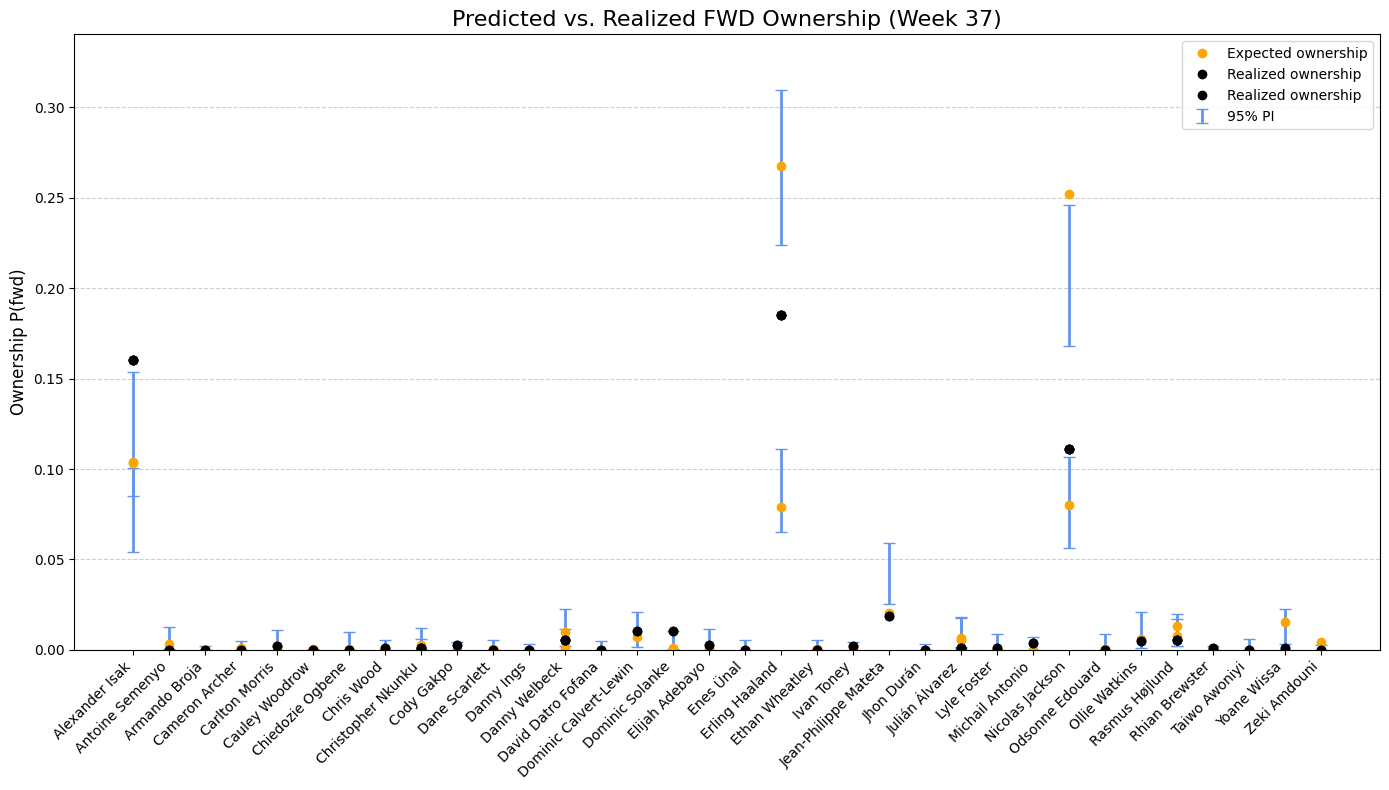

In [293]:
# Get all posterior samples for the 'betas' variable from the trace
num_samples = beta_fwd.shape[0]
print(f"Extracted {num_samples} posterior samples for beta.")

# --- 3. Generate a Prediction for Each Sample ---
# For each of the 2000 beta samples, we generate one possible ownership vector
all_predictions = []
for i in range(num_samples):
    beta_sample = beta_fwd[i]
    # Calculate alpha = exp(X * beta)
    alpha_sample = np.exp(np.dot(X_pca[3], beta_fwd))
    # Sample a prediction from the Dirichlet distribution
    prediction = np.random.dirichlet(alpha_sample)
    all_predictions.append(prediction)

# Convert list of predictions into a numpy array (samples x num_players)
predictions_array = np.array(all_predictions)

# --- 4. Calculate the 95% Prediction Intervals ---
# For each player, find the 2.5th and 97.5th percentile of their predicted ownerships
lower_bounds = np.percentile(predictions_array, 2.5, axis=0)
upper_bounds = np.percentile(predictions_array, 97.5, axis=0)
mean_preds = np.mean(predictions_array, axis=0) # We need a y-value for the error bar center


# --- 5. Plot the Results ---
plt.figure(figsize=(14, 8))
y_err = [mean_preds - lower_bounds, upper_bounds - mean_preds]

# Plot the 95% Prediction Intervals as blue error bars
plt.errorbar(
    x=fwd_names,
    y=mean_preds,
    yerr=y_err,
    fmt='none',
    ecolor='cornflowerblue',
    elinewidth=2,
    capsize=4,
    label='95% PI' # PI = Prediction Interval
)

# Plot the expected ownership as black dots on top
plt.plot(
    fwd_names,
    fwd_probs_est,
    'o',
    color='orange',
    markersize=6,
    label='Expected ownership'
)

# Plot the realized ownership as black dots on top
plt.plot(
    fwd_names,
    fwd_probs_obs,
    'o',
    color='black',
    markersize=6,
    label='Realized ownership'
)

# --- 6. Formatting the Plot ---
plt.title('Predicted vs. Realized FWD Ownership (Week 37)', fontsize=16)
plt.ylabel('Ownership P(fwd)', fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.legend()
plt.ylim(0, max(np.max(upper_bounds), np.max(fwd_probs_obs)) * 1.1) # Set y-axis limit
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

## Generate Portfolios


In [294]:
# --- Step 19: Return W_op ---
# Generate O opponent portfolios[span_17](end_span)
generated_portfolios = sample_opponent_portfolios(
    O=200,
    beta_estimates=all_beta_estimates,
    feature_matrices=X_pca,
    costs=prices,
    budget=100,
    teams = teams
)

# prices[3].shape


Generating 200 opponent portfolios...
95.7
--------------------------->>>>>>>> 1
91.1
--------------------------->>>>>>>> 2
91.9
--------------------------->>>>>>>> 3
91.6
--------------------------->>>>>>>> 4
91.69999999999999
--------------------------->>>>>>>> 5
93.39999999999999
--------------------------->>>>>>>> 6
90.69999999999999
--------------------------->>>>>>>> 7
94.6
--------------------------->>>>>>>> 8
90.5
--------------------------->>>>>>>> 9
90.5
--------------------------->>>>>>>> 10
91.5
--------------------------->>>>>>>> 11
94.39999999999999
--------------------------->>>>>>>> 12
95.0
--------------------------->>>>>>>> 13
90.39999999999999
--------------------------->>>>>>>> 14
92.8
--------------------------->>>>>>>> 15
95.8
--------------------------->>>>>>>> 16
90.5
--------------------------->>>>>>>> 17
90.0
--------------------------->>>>>>>> 18
94.1
--------------------------->>>>>>>> 19
91.3
--------------------------->>>>>>>> 20
91.0
--------------------

In [295]:
Wo_ = []
for i in generated_portfolios:
    # Create a tuple of 0s and 1s for each player
    squad = tuple([1 if id_ in i else 0 for id_ in valid_player_ids])
    Wo_.append(squad)

Output()

Finished [100%]: Average Loss = 20,416
arviz - WARNING - Shape validation failed: input_shape: (1, 1000), minimum_shape: (chains=2, draws=4)


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
delta[0],4.515,0.021,4.478,4.554,0.001,0.000,970.0,1017.0,NaN
delta[1],1.612,0.021,1.574,1.650,0.001,0.000,1011.0,995.0,NaN
delta[2],0.649,0.017,0.619,0.684,0.001,0.000,960.0,830.0,NaN
delta[3],5.592,0.023,5.555,5.640,0.001,0.001,889.0,778.0,NaN
delta[4],4.732,0.019,4.699,4.767,0.001,0.000,909.0,980.0,NaN
...,...,...,...,...,...,...,...,...,...
G_r[195],26.819,0.066,26.691,26.934,0.002,0.002,906.0,737.0,NaN
G_r[196],35.938,0.073,35.799,36.066,0.002,0.002,978.0,1017.0,NaN
G_r[197],27.399,0.067,27.287,27.539,0.002,0.002,919.0,835.0,NaN
G_r[198],40.161,0.071,40.038,40.300,0.003,0.002,755.0,822.0,NaN


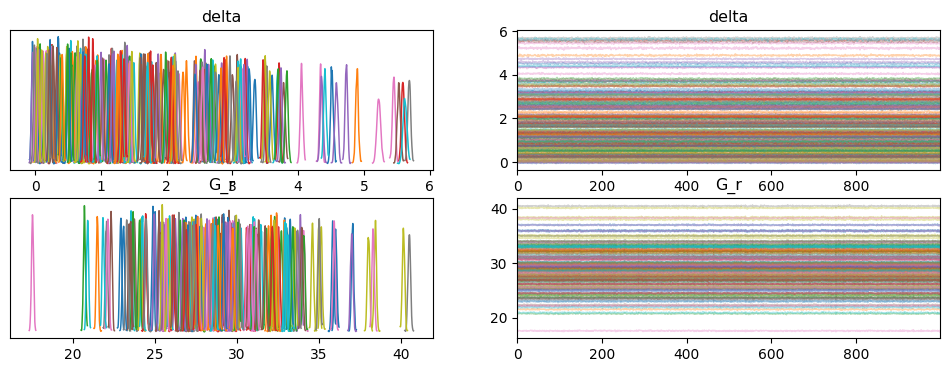

In [296]:
def make_positive_definite(cov_mat, epsilon=1e-6):
    # Ensure symmetry
    cov_mat = (cov_mat + cov_mat.T) / 2

    # Add jitter to diagonal
    jitter = epsilon * np.eye(cov_mat.shape[0])
    return cov_mat + jitter


def monte_carlo_simulation(Wo_, mu_delta, cov_mat, sigma_delta):
    num_player = len(Wo_[0])

    cov_mat = make_positive_definite(cov_mat)

    with pm.Model() as model:
        L = np.linalg.cholesky(make_positive_definite(cov_mat))
        delta = pm.MvNormal("delta", mu=mu_delta, chol=L, shape=num_player)
        # delta = pm.MvNormal("delta", mu=mu_delta, cov=cov_mat, shape=num_player)

        # Compute 90th percentile of performance
        dot_product = pt.dot(Wo_, delta)
        G_r = pm.Deterministic("G_r",  np.percentile(dot_product, 90)) # pt.sort(dot_product)[-int(len(Wo_) * 0.9)])

        approx = pm.fit(method='advi', n=20000)

        trace = approx.sample(1000)
        # trace = pm.sample(
        #     3000,
        #     return_inferencedata=True,
        #     cores=2,
        #     chains=10,
        #     progressbar=True,
        #     target_accept=0.95
        # )

        # G_r_90 = np.percentile(pt.dot(trace.posterior['delta'].values, Wo_), 90)

    return trace
MC_sim_trace = monte_carlo_simulation(Wo_, mu_delta, cov_mat, sigma_delta)

az.plot_trace(MC_sim_trace, var_names=["delta", "G_r"])
az.summary(MC_sim_trace, var_names=["delta", "G_r"])

In [297]:
delta_samples = MC_sim_trace.posterior['delta'].stack(sample=("chain", "draw")).values.T  # shape (N_samples, 226)
G_r_samples   = MC_sim_trace.posterior['G_r'].stack(sample=("chain", "draw")).values.T    # shape (N_samples, 200)

G_r_scalar = np.percentile(G_r_samples, 90, axis=1)  # shape (N_samples,)
print(G_r_scalar.shape, delta_samples.shape)

mu_delta, cov_delta, mu_G, var_G, cov_delta_G, sigma_G = generate_cov_delta(delta_samples, G_r_scalar)


(1000,) (1000, 239)
(1000, 239) (1000,)


In [299]:
lambdas = np.linspace(0.0, 0.5, 6)
best_lambda, best_w, best_prob = optimize_portfolio(W_constraints, mu_delta, cov_delta, mu_G, var_G, cov_delta_G, lambdas, delta_samples, G_r_scalar)
print(f"Best λ: {best_lambda}, Best Probability of Outperforming: {best_prob}")
selected, player_names, total_points = selected_info(best_w, fpl_teams_ids, players_preds, ids)
selected, player_names, total_points

IndexError: index 286 is out of bounds for axis 0 with size 239

# Prev


## GW 36


In [ ]:
players_picked, player_names, total_points = get_optimized_team(36)
print(players_picked, player_names, total_points)

ValueError: Found array with 0 sample(s) (shape=(0, 85)) while a minimum of 1 is required.

## GW 37


In [ ]:
players_picked, player_names, total_points = get_optimized_team(37)
print(players_picked, player_names, total_points)

data successfully cleaned...
starting to generate selction probabilities


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [pg, pd_, pm, pf]


Output()

Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 100 seconds.
There were 2000 divergences after tuning. Increase `target_accept` or reparameterize.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
Generating Squads: 100%|██████████| 1000/1000 [00:08<00:00, 121.35it/s]



Successfully generated 1000 unique squads
Starting to optimize team selection...


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [chol_cov, delta]


Output()

Sampling 2 chains for 1_000 tune and 500 draw iterations (2_000 + 1_000 draws total) took 58 seconds.
c:\Users\Ilyas\anaconda3\envs\Pycaret\Lib\site-packages\arviz\stats\diagnostics.py:592: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
There were 683 divergences after tuning. Increase `target_accept` or reparameterize.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details



🔍 Variable Info:
w[0] (517.0): Binary
w[1] (14.0): Binary
w[2] (388.0): Binary
w[3] (217.0): Binary
w[4] (81.0): Binary
w[5] (147.0): Binary
w[6] (239.0): Binary
w[7] (372.0): Binary
w[8] (247.0): Binary
w[9] (310.0): Binary
w[10] (513.0): Binary
w[11] (233.0): Binary
w[12] (383.0): Binary
w[13] (432.0): Binary
w[14] (398.0): Binary
w[15] (78.0): Binary
w[16] (255.0): Binary
w[17] (489.0): Binary
w[18] (238.0): Binary
w[19] (282.0): Binary
w[20] (146.0): Binary
w[21] (160.0): Binary
w[22] (484.0): Binary
w[23] (24.0): Binary
w[24] (248.0): Binary
w[25] (635.0): Binary
w[26] (42.0): Binary
w[27] (285.0): Binary
w[28] (595.0): Binary
w[29] (491.0): Binary
w[30] (366.0): Binary
w[31] (394.0): Binary
w[32] (99.0): Binary
w[33] (17.0): Binary
w[34] (434.0): Binary
w[35] (421.0): Binary
w[36] (241.0): Binary
w[37] (27.0): Binary
w[38] (450.0): Binary
w[39] (115.0): Binary
w[40] (368.0): Binary
w[41] (654.0): Binary
w[42] (194.0): Binary
w[43] (447.0): Binary
w[44] (101.0): Binary
w[45] (321

## GW 38


In [ ]:
players_picked, player_names, total_points = get_optimized_team(38)
print(players_picked, player_names, total_points)

data successfully cleaned...
starting to generate selction probabilities


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [pg, pd_, pm, pf]


Output()

Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 98 seconds.
There were 2000 divergences after tuning. Increase `target_accept` or reparameterize.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
Generating Squads: 100%|██████████| 1000/1000 [00:08<00:00, 116.82it/s]



Successfully generated 1000 unique squads
Starting to optimize team selection...


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [chol_cov, delta]


Output()

Sampling 2 chains for 1_000 tune and 500 draw iterations (2_000 + 1_000 draws total) took 54 seconds.
c:\Users\Ilyas\anaconda3\envs\Pycaret\Lib\site-packages\arviz\stats\diagnostics.py:592: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
There were 515 divergences after tuning. Increase `target_accept` or reparameterize.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details



🔍 Variable Info:
w[0] (517.0): Binary
w[1] (14.0): Binary
w[2] (388.0): Binary
w[3] (217.0): Binary
w[4] (81.0): Binary
w[5] (147.0): Binary
w[6] (239.0): Binary
w[7] (247.0): Binary
w[8] (77.0): Binary
w[9] (401.0): Binary
w[10] (310.0): Binary
w[11] (233.0): Binary
w[12] (240.0): Binary
w[13] (335.0): Binary
w[14] (432.0): Binary
w[15] (398.0): Binary
w[16] (78.0): Binary
w[17] (255.0): Binary
w[18] (489.0): Binary
w[19] (238.0): Binary
w[20] (282.0): Binary
w[21] (146.0): Binary
w[22] (484.0): Binary
w[23] (687.0): Binary
w[24] (24.0): Binary
w[25] (248.0): Binary
w[26] (42.0): Binary
w[27] (285.0): Binary
w[28] (595.0): Binary
w[29] (491.0): Binary
w[30] (366.0): Binary
w[31] (394.0): Binary
w[32] (99.0): Binary
w[33] (17.0): Binary
w[34] (434.0): Binary
w[35] (421.0): Binary
w[36] (27.0): Binary
w[37] (450.0): Binary
w[38] (115.0): Binary
w[39] (368.0): Binary
w[40] (475.0): Binary
w[41] (194.0): Binary
w[42] (447.0): Binary
w[43] (370.0): Binary
w[44] (101.0): Binary
w[45] (283.

# Current


In [ ]:
def get_optimized_team(sns, gw):
    # gw=38
    data_25_26 = pd.read_csv(f'../FPL predictors/with new features/data/joint/{sns}/merged_player_data.csv')
    players_preds = pd.read_csv(f'../FPL predictors/with new features/models/preds/players_preds_{gw}.csv', index_col=0)
    sns_split = '_'.join(sns.split('-'))
    fpl_teams_ids = pd.read_csv(f'../FPL predictors/with new features/data/vaastav/data/id_dict_{sns_split}.csv')

    # print(players_preds['fpl_name'])
    # # Add fpl_id to player_preds
    players_preds = players_preds.merge(fpl_teams_ids, left_on='fpl_name', right_on='FPL_Name', how='left')
    players_preds.dropna(subset=['FPL_ID'], inplace=True)

    player_ids  = players_preds['FPL_ID'].tolist()

    data, prices, xPts, teams, ids, X_pca = clean_data(players_preds)
    probs = generate_probs(X_pca, betas=[beta_gk, beta_def, beta_mid, beta_fwd])
    Wo = generate_Wo(probs, ids, prices, players_preds,  budget = 100, squads=1_000)
    Wo_, mu_delta, sigma_delta = generate_cov_mat(players_preds, Wo, player_ids, data_25_26)
    delta_samples, G_r_samples = monte_carlo_simulation(Wo_, mu_delta, sigma_delta, num_samples=500)
    parameters = estimate_parameters(delta_samples, G_r_samples)
    mu_delta, cov_delta, mu_G, var_G, cov_delta_G, sigma_G = generate_cov_delta(delta_samples, G_r_samples)
    selected = optimize(mu_delta, mu_G, var_G, sigma_G, cov_delta, gw, player_ids, players_preds, ids)
    players_picked, player_names, total_points = selected_info(selected, players_preds, ids)

    return players_picked, player_names, total_points

In [ ]:
players_picked, player_names, total_points = get_optimized_team('25-26',6)
print(players_picked, player_names, total_points)

c:\Users\Ilyas\anaconda3\envs\Pycaret\Lib\site-packages\sklearn\utils\_array_api.py:472: RuntimeWarning: All-NaN slice encountered
  return xp.asarray(numpy.nanmin(X, axis=axis))
c:\Users\Ilyas\anaconda3\envs\Pycaret\Lib\site-packages\sklearn\utils\_array_api.py:489: RuntimeWarning: All-NaN slice encountered
  return xp.asarray(numpy.nanmax(X, axis=axis))
c:\Users\Ilyas\anaconda3\envs\Pycaret\Lib\site-packages\sklearn\utils\_array_api.py:472: RuntimeWarning: All-NaN slice encountered
  return xp.asarray(numpy.nanmin(X, axis=axis))
c:\Users\Ilyas\anaconda3\envs\Pycaret\Lib\site-packages\sklearn\utils\_array_api.py:489: RuntimeWarning: All-NaN slice encountered
  return xp.asarray(numpy.nanmax(X, axis=axis))
c:\Users\Ilyas\anaconda3\envs\Pycaret\Lib\site-packages\sklearn\utils\_array_api.py:472: RuntimeWarning: All-NaN slice encountered
  return xp.asarray(numpy.nanmin(X, axis=axis))
c:\Users\Ilyas\anaconda3\envs\Pycaret\Lib\site-packages\sklearn\utils\_array_api.py:489: RuntimeWarning: 

data successfully cleaned...
starting to generate selction probabilities


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [pg, pd_, pm, pf]


Output()

Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 194 seconds.
There were 2000 divergences after tuning. Increase `target_accept` or reparameterize.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
Generating Squads: 100%|██████████| 1000/1000 [00:11<00:00, 84.41it/s]



Successfully generated 1000 unique squads
Starting to optimize team selection...


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [chol_cov, delta]


Output()

Sampling 2 chains for 1_000 tune and 500 draw iterations (2_000 + 1_000 draws total) took 262 seconds.
c:\Users\Ilyas\anaconda3\envs\Pycaret\Lib\site-packages\arviz\stats\diagnostics.py:592: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
There were 503 divergences after tuning. Increase `target_accept` or reparameterize.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details



🔍 Variable Info:
w[0] (366): Binary
w[1] (431): Binary
w[2] (139): Binary
w[3] (314): Binary
w[4] (101): Binary
w[5] (1): Binary
w[6] (253): Binary
w[7] (32): Binary
w[8] (565): Binary
w[9] (182): Binary
w[10] (287): Binary
w[11] (628): Binary
w[12] (341): Binary
w[13] (679): Binary
w[14] (33): Binary
w[15] (470): Binary
w[16] (502): Binary
w[17] (469): Binary
w[18] (220): Binary
w[19] (670): Binary
w[20] (627): Binary
w[21] (67): Binary
w[22] (116): Binary
w[23] (610): Binary
w[24] (406): Binary
w[25] (73): Binary
w[26] (74): Binary
w[27] (372): Binary
w[28] (316): Binary
w[29] (447): Binary
w[30] (685): Binary
w[31] (11): Binary
w[32] (318): Binary
w[33] (261): Binary
w[34] (375): Binary
w[35] (662): Binary
w[36] (569): Binary
w[37] (476): Binary
w[38] (256): Binary
w[39] (682): Binary
w[40] (574): Binary
w[41] (144): Binary
w[42] (440): Binary
w[43] (573): Binary
w[44] (603): Binary
w[45] (631): Binary
w[46] (111): Binary
w[47] (474): Binary
w[48] (511): Binary
w[49] (148): Binary


In [ ]:
import requests
recoms = [
    'Noni Madueke', 'Eberechi Eze',
    'Chris Richards', 'Nathaniel Clyne', 'Bernd Leno',
    'Emile Smith Rowe', 'Lukas Nmecha', 'Ibrahim Sangaré',
    'Niclas Füllkrug', 'Jørgen Strand Larsen', 'David Møller Wolfe']

fpl = requests.get('https://fantasy.premierleague.com/api/bootstrap-static/').json()
fpl = pd.DataFrame(fpl['elements'])

In [ ]:
fpl['total_points']

0      28
1       0
2       0
3       0
4      38
       ..
737    11
738     6
739     5
740    10
741     5
Name: total_points, Length: 742, dtype: int64

In [ ]:
ids = pd.read_csv('../FPL predictors/with new features/data/vaastav/data/id_dict_25_26.csv')

total_points = 0

for player in recoms:
    fpl_id = ids[ids['FPL_Name'] == player]['FPL_ID'].values[0]
    points = fpl[fpl['id'] == fpl_id]['total_points'].values[0]
    print(player, points)
    total_points += points

print('Total points: ', total_points)

Noni Madueke 10
Eberechi Eze 16
Chris Richards 30
Nathaniel Clyne 1
Bernd Leno 18
Emile Smith Rowe 11
Lukas Nmecha 11
Ibrahim Sangaré 11
Niclas Füllkrug 8
Jørgen Strand Larsen 7
David Møller Wolfe 6
Total points:  129
